# 📘 Bölüm 9: Yapay Sinir Ağlarına Giriş(Artificial Neural Networks)
### Kaynak: *Hands-On Machine Learning with Scikit-Learn and PyTorch* — Aurélien Géron

> Bu notebook, kitabın 9. bölümündeki tüm konuları Türkçe açıklamalar ve çalışan Python kodlarıyla birlikte sunar.
> GitHub'da paylaşıma ve yeniden kullanıma uygundur.

---

## 📋 İçindekiler

1. [Giriş ve Motivasyon](#giris)
2. [Biyolojik Nöronlardan Yapay Nöronlara](#biyolojik)
   - 2.1 [Biyolojik Nöronlar](#bio_neuron)
   - 2.2 [Nöronlarla Mantıksal Hesaplamalar](#mantik)
   - 2.3 [Perceptron](#perceptron)
   - 2.4 [Çok Katmanlı Perceptron (MLP) ve Geri Yayılım](#mlp)
3. [Scikit-Learn ile MLP Oluşturma ve Eğitme](#sklearn)
   - 3.1 [Regresyon MLP'leri](#regresyon)
   - 3.2 [Sınıflandırma MLP'leri](#siniflandirma)
4. [Hiperparametre Ayarlama Kılavuzu](#hiperparametre)
   - 4.1 [Gizli Katman Sayısı](#katman_sayisi)
   - 4.2 [Katman Başına Nöron Sayısı](#noron_sayisi)
   - 4.3 [Öğrenme Hızı](#ogrenme_hizi)
   - 4.4 [Batch Boyutu](#batch)
   - 4.5 [Diğer Hiperparametreler](#diger)
5. [Özet](#ozet)


---
<a id='giris'></a>
## 1.  Giriş ve Motivasyon

Kuşlar bize uçmayı, cırt-cırtlı bitkiler Velcro'yu ilham verdi. Aynı mantıkla, doğadaki en karmaşık ve güçlü bilgi işlem sistemi olan **insan beynine** bakarak akıllı makineler tasarlamaya çalışabiliriz. İşte bu düşünceden **Yapay Sinir Ağları (YSA / ANN)** doğdu.

### Neden Yapay Sinir Ağları?

YSA'lar derin öğrenmenin (deep learning) temel taşıdır. Şu alanlarda devrimsel başarılar elde etmişlerdir:

| Uygulama | Örnek |
|---|---|
| Görüntü Sınıflandırma | Google Images |
| Konuşma Tanıma | Siri, Google Assistant |
| Sohbet Botları | ChatGPT, Claude |
| Video Öneri | YouTube |
| Protein Katlanması | DeepMind AlphaFold |

### Tarihsel Dalgalar

YSA'ların tarihi, üç büyük dalga ile özetlenebilir:

| Dönem | Gelişme |
|---|---|
| 1943 | McCulloch ve Pitts'in ilk YSA modeli |
| 1960'lar | 1. kış dönemi – beklentiler karşılanmadı |
| 1980'ler | Yeniden canlanma – bağlantıcılık (connectionism) |
| 1990'lar | 2. kış dönemi – SVM ve diğer yöntemler öne çıktı |
| 2010'lar+ | Büyük veri, GPU gücü ve Transformer mimarisiyle patlama |

### Bu Sefer Neden Farklı?

- **Büyük veri:** Devasa veri setleri artık mevcut
- **GPU gücü:** Paralel hesaplama YSA'ları için idealdir
- **Gelişmiş algoritmalar:** Küçük ama kritik iyileştirmeler
- **Yerel minimumlara takılma sorunu:** Büyük ağlarda pratikte bu büyük sorun değil
- **Transformer (2017):** Her türlü veriyi (metin, görüntü, ses) işleyebilen devrimsel mimari
- **Virtüöz döngü:** Yatırım → Başarı → Daha fazla yatırım

---
<a id='biyolojik'></a>
## 2. 🧠 Biyolojik Nöronlardan Yapay Nöronlara

<a id='bio_neuron'></a>
### 2.1 Biyolojik Nöronlar

Yapay nöronları anlamak için önce biyolojik nörona bakalım:

```
Biyolojik Nöron Yapısı:

  [Dendritler] ──→ [Hücre Gövdesi / Çekirdek] ──→ [Akson] ──→ [Sinaptik Terminaller]
      ↑                                                              ↓
  Giriş sinyalleri alır                              Diğer nöronlara sinyal gönderir
```

**Temel Bileşenler:**
- **Hücre gövdesi (soma):** Çekirdeği ve hücrenin karmaşık bileşenlerini barındırır
- **Dendritler:** Diğer nöronlardan sinyal alan dallanmış uzantılar
- **Akson:** Sinyali diğer nöronlara ileten uzun uzantı
- **Sinaptik terminaller (sinapslar):** Diğer nöronların dendritlerinden yüzlerce nanometre uzakta duran ve kimyasal sinyal (nörotransmitter) salan uç yapılar
- **Aksiyon potansiyeli (AP):** Nöronun ürettiği kısa elektrik impulsu

**Nasıl Çalışır?**

Bir nöron, bağlı olduğu nöronlardan yeterli miktarda nörotransmitter aldığında kendi aksiyon potansiyelini üretir ve bunu aksonu aracılığıyla iletir. Bu süreç bir "ateşleme" (firing) olarak adlandırılır.

**Beyin Mimarisi:**

Milyarlarca nöron, binlerce bağlantıyla birbirine bağlıdır. Bu basit nöronların oluşturduğu ağ, son derece karmaşık hesaplamalar yapabilir. Beyin kabuğunda (serebral korteks) nöronlar genellikle **ardışık katmanlar** halinde organize olur — bu yapı, yapay sinir ağlarımıza ilham verir.

### Global Plot Settings (Global Grafik Ayarları)

Tüm notebook boyunca geçerli olacak grafik görünüm ayarları burada bir kez yapılır.  
Bu sayede her grafik için tekrar tekrar aynı ayarları yazmak gerekmez.

In [1]:
import matplotlib.pyplot as plt

# plt.rc(): Matplotlib'in global (genel) yapılandırma ayarlarını değiştirir.
# 'font'  → Genel yazı tipi ailesi ayarı
# 'axes'  → Grafik eksenlerine ait ayarlar
# 'legend'→ Açıklama kutusuna (legend) ait ayarlar
# 'xtick' / 'ytick' → X ve Y eksenlerindeki tick (bölümleme) etiket boyutları

# size=14    → Ana yazı boyutu 14 punto
# labelsize  → Eksen etiketleri boyutu (xlabel, ylabel)
# titlesize  → Grafik başlığı boyutu
# fontsize   → Legend (açıklama kutusu) yazı boyutu
# labelsize=10 (xtick/ytick) → Eksen üzerindeki sayısal etiketler 10 punto

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

print("✅ Global plot settings (grafik ayarları) yapılandırıldı.")
print("   font size (yazı boyutu)  : 14")
print("   axes label size          : 14")
print("   tick label size          : 10")

✅ Global plot settings (grafik ayarları) yapılandırıldı.
   font size (yazı boyutu)  : 14
   axes label size          : 14
   tick label size          : 10


<a id='mantik'></a>
### 2.2 Nöronlarla Mantıksal Hesaplamalar

McCulloch ve Pitts (1943), biyolojik nöronun basit bir hesaplama modelini önerdi:

- Bir veya daha fazla **ikili (binary) girdi**
- Belirli sayıdan fazla girdi aktifse çıktı **1**, aksi halde **0**

Bu kadar basit bir model bile mantıksal işlemler yapabilir:

In [1]:
# McCulloch-Pitts Nöronu ile Mantıksal İşlemler
# Bir nöron, en az 2 aktif girdi varsa ateşlenir varsayımı

def mc_pitts_neuron(inputs, threshold=2):
    """Basit McCulloch-Pitts yapay nöronu"""
    return 1 if sum(inputs) >= threshold else 0

# AND kapısı: Her iki giriş de 1 olmalı
print("=== AND Kapısı ===")
print(f"AND(0, 0) = {mc_pitts_neuron([0, 0])}")
print(f"AND(0, 1) = {mc_pitts_neuron([0, 1])}")
print(f"AND(1, 0) = {mc_pitts_neuron([1, 0])}")
print(f"AND(1, 1) = {mc_pitts_neuron([1, 1])}")

# OR kapısı: En az bir giriş 1 olmalı (threshold=1)
print("\n=== OR Kapısı ===")
for a, b in [(0,0),(0,1),(1,0),(1,1)]:
    print(f"OR({a}, {b})  = {mc_pitts_neuron([a, b], threshold=1)}")

# NOT kapısı: A=1 iken B inhibitör (engelleyici) girdi
print("\n=== NOT Kapısı (inhibitör bağlantı) ===")
print("A=1 sabit, B değişiyor:")
print(f"NOT(0) = {mc_pitts_neuron([1, 0], threshold=2)} → 1")
print(f"NOT(1) = {mc_pitts_neuron([1, -1], threshold=2)} → 0")
print("\nNot: Inhibitör bağlantı, girdiyi negatifleştirerek uygulanır")

=== AND Kapısı ===
AND(0, 0) = 0
AND(0, 1) = 0
AND(1, 0) = 0
AND(1, 1) = 1

=== OR Kapısı ===
OR(0, 0)  = 0
OR(0, 1)  = 1
OR(1, 0)  = 1
OR(1, 1)  = 1

=== NOT Kapısı (inhibitör bağlantı) ===
A=1 sabit, B değişiyor:
NOT(0) = 0 → 1
NOT(1) = 0 → 0

Not: Inhibitör bağlantı, girdiyi negatifleştirerek uygulanır


<a id='perceptron'></a>
### 2.3 Perceptron

1957'de Frank Rosenblatt tarafından icat edilen **Perceptron**, en basit YSA mimarisinin ilk örneğidir.

#### Eşik Mantık Birimi (TLU / LTU)

Perceptron'un temel bileşeni **Eşik Mantık Birimi (Threshold Logic Unit - TLU)**'dir:

$$z = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \mathbf{w}^\top \mathbf{x} + b$$

$$h_\mathbf{w}(\mathbf{x}) = \text{step}(z)$$

#### Yaygın Adım Fonksiyonları

**Heaviside Adım Fonksiyonu:**
$$\text{heaviside}(z) = \begin{cases} 0 & \text{eğer } z < 0 \\ 1 & \text{eğer } z \geq 0 \end{cases}$$

**İşaret (Sign) Fonksiyonu:**
$$\text{sgn}(z) = \begin{cases} -1 & \text{eğer } z < 0 \\ 0 & \text{eğer } z = 0 \\ +1 & \text{eğer } z > 0 \end{cases}$$

---
<a id='perceptron'></a>


### Temel Kavramlar

| Terim | Türkçe | Açıklama |
|---|---|---|
| **Perceptron** | Algılayıcı | Frank Rosenblatt (1957) tarafından icat edilen en basit ANN (Yapay Sinir Ağı) mimarisi |
| **TLU** | Eşik Mantık Birimi | Threshold Logic Unit — Perceptron'un temel hesaplama birimi |
| **decision boundary** | karar sınırı | İki sınıfı ayıran geometrik çizgi/yüzey |
| **linear separability** | doğrusal ayrılabilirlik | İki sınıfın bir doğru ile ayrılabilmesi koşulu |
| **convergence** | yakınsama | Algoritmanın kararlı bir çözüme ulaşması |

**Perceptron nasıl çalışır?**

$$z = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \mathbf{w}^\top \mathbf{x} + b$$
$$\hat{y} = \text{step}(z)$$

Ağırlıklı toplamı alır, bir step function (adım fonksiyonu) uygular, 0 ya da 1 çıktı verir.

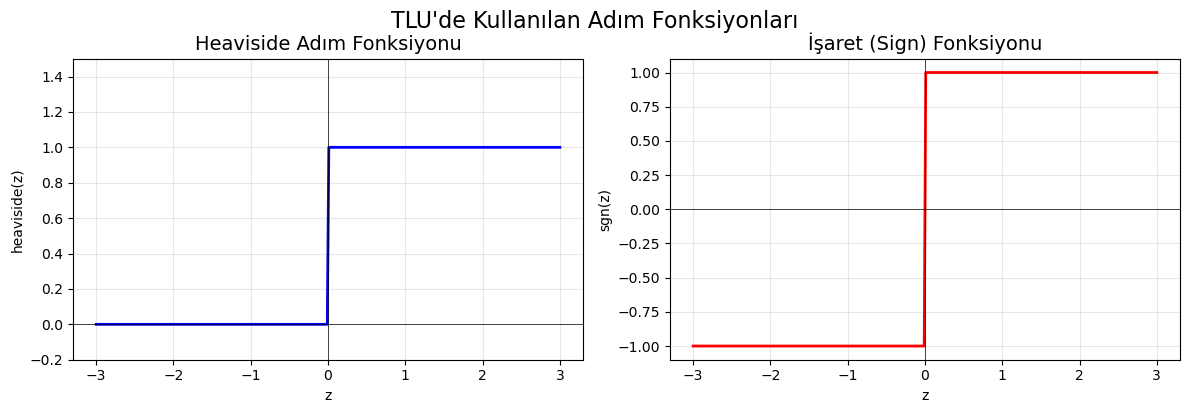

✅ Grafik kaydedildi: adim_fonksiyonlari.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Adım fonksiyonlarını görselleştirelim
z = np.linspace(-3, 3, 300)

heaviside = np.where(z >= 0, 1, 0)
sign = np.sign(z)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(z, heaviside, 'b-', linewidth=2)
ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax1.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
ax1.set_title('Heaviside Adım Fonksiyonu', fontsize=14)
ax1.set_xlabel('z')
ax1.set_ylabel('heaviside(z)')
ax1.set_ylim(-0.2, 1.5)
ax1.grid(True, alpha=0.3)

ax2.plot(z, sign, 'r-', linewidth=2)
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax2.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
ax2.set_title('İşaret (Sign) Fonksiyonu', fontsize=14)
ax2.set_xlabel('z')
ax2.set_ylabel('sgn(z)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('TLU\'de Kullanılan Adım Fonksiyonları', fontsize=16, y=1.02)
plt.savefig('adim_fonksiyonlari.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Grafik kaydedildi: adim_fonksiyonlari.png")

#### 2.3.1 Perceptron Katman Denklemi

Bir perceptron katmanı, TLU'lardan oluşur. Matris formunda hesaplama:

$$h_{\mathbf{W}, \mathbf{b}}(\mathbf{X}) = \phi(\mathbf{X} \mathbf{W} + \mathbf{b})$$

Burada:
- **X**: Girdi matrisi (satır = örnek, sütun = özellik)
- **W**: Ağırlık matrisi (satır = girdi, sütun = nöron)
- **b**: Sapma (bias) vektörü
- **ϕ**: Aktivasyon fonksiyonu (Heaviside)

#### Perceptron Öğrenme Kuralı

$$w_{i,j}^{(\text{sonraki adım})} = w_{i,j} + \eta (\hat{y}_j - y_j) x_i$$

- $\eta$: Öğrenme hızı (learning rate)
- $\hat{y}_j$: Tahmin edilen çıktı
- $y_j$: Gerçek hedef
- $x_i$: i'nci girdi özelliği

In [3]:
import numpy as np

class BenimPerceptronum:
    """Sıfırdan yazılmış basit Perceptron uygulaması"""
    
    def __init__(self, ogrenme_hizi=0.1, iterasyon=1000):
        self.ogrenme_hizi = ogrenme_hizi
        self.iterasyon = iterasyon
    
    def heaviside(self, z):
        return np.where(z >= 0, 1, 0)
    
    def fit(self, X, y):
        n_ornek, n_ozellik = X.shape
        # Ağırlıkları ve sapma terimini sıfırla başlat
        self.agirliklar = np.zeros(n_ozellik)
        self.sapma = 0
        
        for iterasyon in range(self.iterasyon):
            hata_var = False
            for xi, yi in zip(X, y):
                # İleri geçiş (forward pass)
                z = np.dot(xi, self.agirliklar) + self.sapma
                y_tahmin = self.heaviside(z)
                
                # Perceptron güncelleme kuralı
                guncelleme = self.ogrenme_hizi * (yi - y_tahmin)
                self.agirliklar += guncelleme * xi
                self.sapma += guncelleme
                
                if guncelleme != 0:
                    hata_var = True
            
            if not hata_var:
                print(f"✅ {iterasyon+1}. iterasyonda yakınsadı")
                break
        return self
    
    def predict(self, X):
        z = np.dot(X, self.agirliklar) + self.sapma
        return self.heaviside(z)


# AND kapısı verisiyle eğitelim
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0, 0, 0, 1])  # AND: sadece her ikisi de 1 ise 1

perceptron = BenimPerceptronum(ogrenme_hizi=0.1, iterasyon=100)
perceptron.fit(X_and, y_and)

print(f"Öğrenilen ağırlıklar: {perceptron.agirliklar}")
print(f"Öğrenilen sapma: {perceptron.sapma}")
print("\nAND Kapısı Tahminleri:")
for xi, yi in zip(X_and, y_and):
    tahmin = perceptron.predict(xi.reshape(1,-1))[0]
    print(f"  AND{tuple(xi)} = {tahmin} ({'✓' if tahmin == yi else '✗'})")

✅ 4. iterasyonda yakınsadı
Öğrenilen ağırlıklar: [0.2 0.1]
Öğrenilen sapma: -0.20000000000000004

AND Kapısı Tahminleri:
  AND(0, 0) = 0 (✓)
  AND(0, 1) = 0 (✓)
  AND(1, 0) = 0 (✓)
  AND(1, 1) = 1 (✓)


#### Perceptron'un Sınırlamaları

Perceptron **doğrusal olarak ayrılabilir** problemleri çözebilir, ancak **XOR problemi** gibi doğrusal olmayan problemleri çözemez:

| A | B | A XOR B |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

XOR, tek bir doğru çizgiyle ayrılamaz. Bu sınırlama, Minsky ve Papert (1969) tarafından gösterilmiş ve yapay sinir ağlarına olan ilgiyi 1. kış dönemine sürüklemiştir.

**Çözüm:** Çok katmanlı perceptron (MLP)!

/var/folders/kz/lshxkfvx5f3d4x28v2tdd8gc0000gn/T/ipykernel_90549/33865513.py:61: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
/var/folders/kz/lshxkfvx5f3d4x28v2tdd8gc0000gn/T/ipykernel_90549/33865513.py:61: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
/var/folders/kz/lshxkfvx5f3d4x28v2tdd8gc0000gn/T/ipykernel_90549/33865513.py:62: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.savefig('xor_problemi.png', dpi=120, bbox_inches='tight')
/var/folders/kz/lshxkfvx5f3d4x28v2tdd8gc0000gn/T/ipykernel_90549/33865513.py:62: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig('xor_problemi.png', dpi=120, bbox_inches='tight')
/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


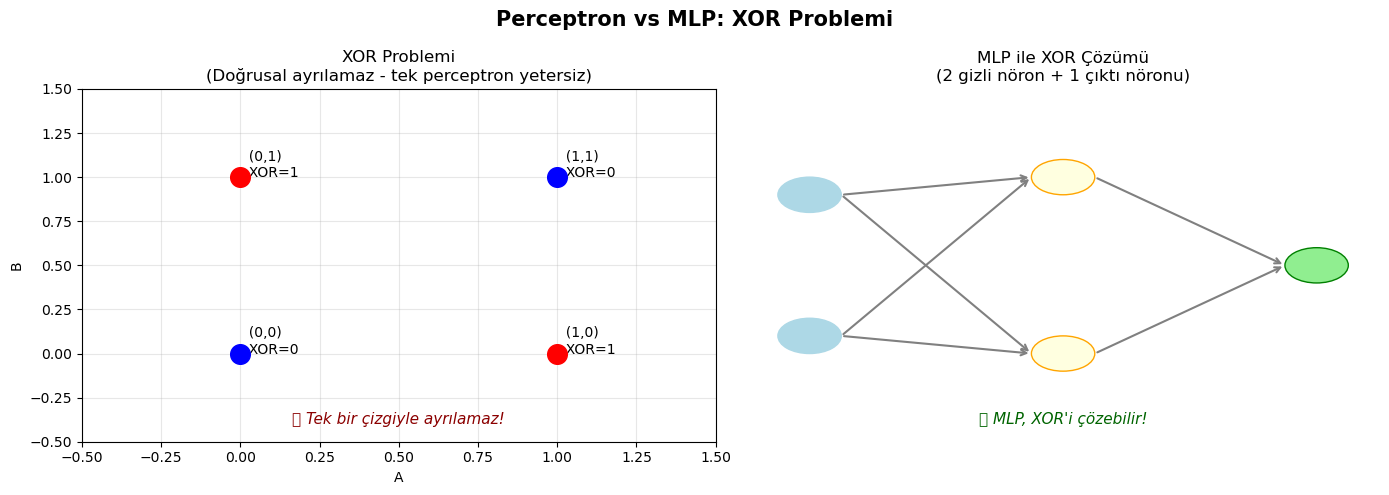


MLP ile XOR Doğrulama (elle ayarlanmış ağırlıklar):
  XOR(0, 0) = 0 (beklenen: 0) ✓
  XOR(0, 1) = 1 (beklenen: 1) ✓
  XOR(1, 0) = 1 (beklenen: 1) ✓
  XOR(1, 1) = 0 (beklenen: 0) ✓


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# XOR problemi görselleştirmesi
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]])
y_xor = np.array([0, 1, 1, 0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: XOR problemi - doğrusal ayrılamaz
colors = ['blue' if label == 0 else 'red' for label in y_xor]
for i, (point, label) in enumerate(zip(X_xor, y_xor)):
    axes[0].scatter(point[0], point[1], c=colors[i], s=200, zorder=5)
    axes[0].annotate(f'  ({point[0]},{point[1]})\n  XOR={label}', 
                     xy=point, fontsize=10)

axes[0].set_xlim(-0.5, 1.5)
axes[0].set_ylim(-0.5, 1.5)
axes[0].set_title('XOR Problemi\n(Doğrusal ayrılamaz - tek perceptron yetersiz)', fontsize=12)
axes[0].set_xlabel('A')
axes[0].set_ylabel('B')
axes[0].grid(True, alpha=0.3)
axes[0].text(0.5, -0.4, '❌ Tek bir çizgiyle ayrılamaz!', 
             ha='center', fontsize=11, color='darkred', style='italic')

# Sağ: MLP'nin XOR çözümü - devre şeması
axes[1].axis('off')
axes[1].set_title('MLP ile XOR Çözümü\n(2 gizli nöron + 1 çıktı nöronu)', fontsize=12)

# Giriş nöronları
axes[1].add_patch(plt.Circle((0.1, 0.7), 0.05, color='lightblue', zorder=5))
axes[1].text(0.1, 0.7, 'A', ha='center', va='center', fontweight='bold')
axes[1].add_patch(plt.Circle((0.1, 0.3), 0.05, color='lightblue', zorder=5))
axes[1].text(0.1, 0.3, 'B', ha='center', va='center', fontweight='bold')

# Gizli katman nöronları
axes[1].add_patch(plt.Circle((0.5, 0.75), 0.05, color='lightyellow', ec='orange', zorder=5))
axes[1].text(0.5, 0.75, 'H1', ha='center', va='center', fontsize=8)
axes[1].add_patch(plt.Circle((0.5, 0.25), 0.05, color='lightyellow', ec='orange', zorder=5))
axes[1].text(0.5, 0.25, 'H2', ha='center', va='center', fontsize=8)

# Çıktı nöronu
axes[1].add_patch(plt.Circle((0.9, 0.5), 0.05, color='lightgreen', ec='green', zorder=5))
axes[1].text(0.9, 0.5, 'XOR', ha='center', va='center', fontsize=7)

# Bağlantılar
for (x1, y1), (x2, y2) in [
    ((0.15, 0.7), (0.45, 0.75)), ((0.15, 0.7), (0.45, 0.25)),
    ((0.15, 0.3), (0.45, 0.75)), ((0.15, 0.3), (0.45, 0.25)),
    ((0.55, 0.75), (0.85, 0.5)), ((0.55, 0.25), (0.85, 0.5))
]:
    axes[1].annotate('', xy=(x2,y2), xytext=(x1,y1),
                     arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

axes[1].text(0.5, 0.05, '✅ MLP, XOR\'i çözebilir!', 
             ha='center', fontsize=11, color='darkgreen', style='italic')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.suptitle('Perceptron vs MLP: XOR Problemi', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('xor_problemi.png', dpi=120, bbox_inches='tight')
plt.show()

# XOR için MLP çözümünü doğrulayalım (elle ayarlanmış ağırlıklar)
print("\nMLP ile XOR Doğrulama (elle ayarlanmış ağırlıklar):")
def mlp_xor(A, B):
    # Gizli katman
    h1 = 1 if (A*1 + B*1 - 0.5) >= 0 else 0   # OR benzeri
    h2 = 1 if (A*1 + B*1 - 1.5) >= 0 else 0   # AND benzeri
    # Çıktı katmanı
    out = 1 if (h1*1 + h2*(-1) - 0.5) >= 0 else 0  # OR AND NOT AND
    return out

for A, B in [(0,0),(0,1),(1,0),(1,1)]:
    beklenen = A ^ B  # Python XOR operatörü
    tahmin = mlp_xor(A, B)
    print(f"  XOR({A}, {B}) = {tahmin} (beklenen: {beklenen}) {'✓' if tahmin == beklenen else '✗'}")

## 2.3.2 Örnekle Pekiştirme

### 1.Iris Veri Setinde Perceptron Eğitimi

In [11]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

# ── Veri Yükleme ──────────────────────────────────────────────────────────────
# load_iris(): 150 çiçek örneği, 4 özellik (sepal length/width, petal length/width),
#              3 sınıf (setosa=0, versicolor=1, virginica=2) içeren klasik veri seti.
# as_frame=True: numpy array yerine pandas DataFrame döndürür.
#                Bu, sütun adlarıyla kolay erişim sağlar.
iris = load_iris(as_frame=True)

# ── Feature (Özellik) Seçimi ───────────────────────────────────────────────────
# Sadece 2 özellik seçiyoruz: petal length (taç yaprak uzunluğu) ve
#                              petal width  (taç yaprak genişliği)
# Neden 2 özellik? 2D (iki boyutlu) görselleştirme için.
# .values: DataFrame'i numpy array'e dönüştürür — Scikit-Learn bunu bekler.
X = iris.data[["petal length (cm)", "petal width (cm)"]].values

# ── Label (Etiket) Oluşturma — Binary Classification (İkili Sınıflandırma) ────
# iris.target: 0, 1 veya 2 değerleri (3 sınıf)
# == 0 : sadece setosa türünü (sınıf 0) tespit etmeye çalışıyoruz
# Sonuç: Boolean (True/False) array → True = Iris setosa, False = diğerleri
# Bu klasik "One vs Rest" (bire karşı hepsi) yaklaşımının en basit halidir.
y = (iris.target == 0)  # True: Iris setosa, False: diğer türler

# ── Model Tanımlama ve Eğitim ──────────────────────────────────────────────────
# Perceptron(): Scikit-Learn'ün Perceptron sınıfı.
#   random_state=42: Ağırlıkların ilk değerlerini (initialization) sabitler,
#                    böylece her çalıştırmada aynı sonuç elde edilir.
# .fit(X, y): Modeli eğitim verisiyle eğitir.
#   Perceptron öğrenme kuralını iteratif (yinelemeli) uygular:
#   w ← w + η(y_gerçek - y_tahmin) * x
#   Veri doğrusal olarak ayrılabilirse eğitim durur (convergence).
per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)

# ── Yeni Örneklerle Tahmin ────────────────────────────────────────────────────
# X_new: Hiç görülmemiş 2 yeni çiçek örneği
#   [2, 0.5] → petal length=2 cm, petal width=0.5 cm
#   [3, 1  ] → petal length=3 cm, petal width=1.0 cm
# .predict(): Eğitilmiş modeli kullanarak sınıf tahmini yapar.
#             Döndürülen değer: [True, False] veya [False, True] gibi Boolean array
X_new = [[2, 0.5], [3, 1]]
y_pred = per_clf.predict(X_new)

print("Perceptron Modeli Eğitildi!")
print(f"  Öğrenilen weight (ağırlık) vektörü: {per_clf.coef_}")
print(f"  Öğrenilen bias (sapma) terimi    : {per_clf.intercept_}")
print(f"  Yeni tahminler: {y_pred}")
print(f"    → [2, 0.5] için: {'Iris setosa' if y_pred[0] else 'Iris setosa DEĞİL'}")
print(f"    → [3, 1.0] için: {'Iris setosa' if y_pred[1] else 'Iris setosa DEĞİL'}")

Perceptron Modeli Eğitildi!
  Öğrenilen weight (ağırlık) vektörü: [[-1.4 -2.2]]
  Öğrenilen bias (sapma) terimi    : [4.]
  Yeni tahminler: [ True False]
    → [2, 0.5] için: Iris setosa
    → [3, 1.0] için: Iris setosa DEĞİL


### 2.Perceptron ile SGDClassifier Eşdeğerliği

Scikit-Learn'ün `Perceptron` sınıfı aslında `SGDClassifier`'ın özel bir durumudur.  
Aynı sonuçları üreten iki farklı yazım biçimi olduğunu gösterelim:

In [13]:
from sklearn.linear_model import SGDClassifier

# SGDClassifier (Stochastic Gradient Descent Classifier — Rassal Gradyan İnişli Sınıflandırıcı)
# ile Perceptron'un tam olarak aynı modeli nasıl ürettiğini gösterir.

# SGDClassifier parametreleri:
#   loss="perceptron"
#       → Kayıp fonksiyonu olarak Perceptron öğrenme kuralını kullanır.
#         Perceptron kaybı: max(0, -y * (w·x + b))  (hinge loss'un özel hali)
#         Yanlış sınıflandırılan örnekler için gradient (gradyan) hesaplar,
#         doğru sınıflandırılanlar için sıfır gradyan döner.
#
#   penalty=None
#       → Regularization (düzenlileştirme) yok.
#         Standart Perceptron herhangi bir ceza terimi kullanmaz.
#         (penalty='l2' olsaydı bu bir Ridge sınıflandırıcı olurdu)
#
#   learning_rate="constant"
#       → Learning rate (öğrenme hızı) eğitim boyunca sabit kalır.
#         Alternatifler: "optimal", "invscaling", "adaptive"
#         Perceptron tanım gereği sabit öğrenme hızı kullanır.
#
#   eta0=1
#       → Sabit learning rate değeri = 1.
#         Klasik Perceptron'da η (eta) = 1 kullanılır.
#
#   random_state=42
#       → Reproducibility (tekrarlanabilirlik) için seed (tohum) değeri.

sgd_clf = SGDClassifier(
    loss="perceptron",
    penalty=None,
    learning_rate="constant",
    eta0=1,
    random_state=42
)
sgd_clf.fit(X, y)

# assert: İki modelin ağırlık matrislerinin ve bias vektörlerinin
# tamamen aynı olduğunu doğrular.
# .coef_: Öğrenilen ağırlık matrisi (weight matrix)
# .intercept_: Öğrenilen sapma (bias) terimi
# .all(): Tüm elemanların True (eşit) olduğunu kontrol eder.
assert (sgd_clf.coef_ == per_clf.coef_).all(), "Ağırlıklar eşit değil!"
assert (sgd_clf.intercept_ == per_clf.intercept_).all(), "Bias'lar eşit değil!"

print("✅ SGDClassifier ile Perceptron tamamen aynı modeli üretiyor!")
print()
print("Perceptron   coef_       :", per_clf.coef_)
print("SGDClassifier coef_      :", sgd_clf.coef_)
print()
print("Perceptron   intercept_  :", per_clf.intercept_)
print("SGDClassifier intercept_ :", sgd_clf.intercept_)
print()
print("Özet:")
print("  Perceptron(random_state=42)")
print("  ≡ SGDClassifier(loss='perceptron', penalty=None,")
print("                  learning_rate='constant', eta0=1)")

✅ SGDClassifier ile Perceptron tamamen aynı modeli üretiyor!

Perceptron   coef_       : [[-1.4 -2.2]]
SGDClassifier coef_      : [[-1.4 -2.2]]

Perceptron   intercept_  : [4.]
SGDClassifier intercept_ : [4.]

Özet:
  Perceptron(random_state=42)
  ≡ SGDClassifier(loss='perceptron', penalty=None,
                  learning_rate='constant', eta0=1)


### 3.Decision Boundary (Karar Sınırı) Görselleştirmesi

Perceptron'un öğrendiği karar sınırını 2D uzayda görselleştirelim.  
Dikkat: Perceptron veriyi doğrusal olarak ayırabildiği anda durur — sınır bir sınıfa çok yakın olabilir.

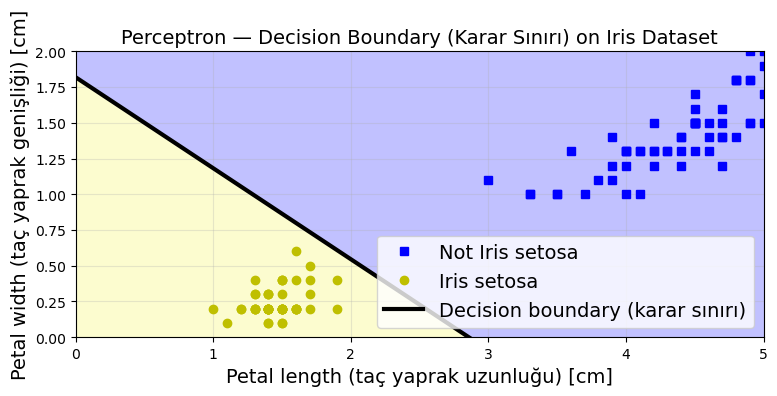


⚠️  Önemli Not:
Perceptron veriyi doğrusal ayırabildiği an durur.
Bu yüzden karar sınırı bir sınıfa çok yakın olabilir.
Logistic Regression (Lojistik Regresyon) bu problemi çözer:
  → Margin (sınır payı) maksimize eder
  → Probability (olasılık) tahmin eder
  → Regularization (düzenlileştirme) desteği vardır


In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ── Decision Boundary (Karar Sınırı) Hesaplama ────────────────────────────────
# Perceptron'un öğrendiği karar fonksiyonu:
#   w0*x0 + w1*x1 + b = 0  (bu bir doğru denklemidir)
# x1 cinsinden çözersek:
#   x1 = (-w0/w1)*x0 + (-b/w1)
#   yani: x1 = a*x0 + b_intercept (y = mx + n doğru denklemi)

# coef_[0, 0]: w0 → petal length'e ait ağırlık
# coef_[0, 1]: w1 → petal width'e ait ağırlık
# intercept_: b → bias terimi
a = -per_clf.coef_[0, 0] / per_clf.coef_[0, 1]   # eğim (slope)
b = -per_clf.intercept_ / per_clf.coef_[0, 1]     # y-kesişim (y-intercept)

# ── Mesh Grid (Izgara) Oluşturma ───────────────────────────────────────────────
# Grafik sınırları: x-ekseni [0,5], y-ekseni [0,2]
axes = [0, 5, 0, 2]

# np.meshgrid(): 2 boyutlu ızgara koordinatları oluşturur.
#   Her piksel için (x0, x1) koordinat çifti elde ederiz.
#   Bu, arka planı boyamak (contourf) için gereklidir.
# np.linspace(start, stop, num): start ile stop arasında eşit aralıklı num sayı
# reshape(-1, 1): 1D array'i sütun vektörüne dönüştürür
x0, x1 = np.meshgrid(
    np.linspace(axes[0], axes[1], 500).reshape(-1, 1),  # x-ekseni için 500 nokta
    np.linspace(axes[2], axes[3], 200).reshape(-1, 1),  # y-ekseni için 200 nokta
)
# np.c_[]: İki array'i sütun sütun birleştirir.
#   ravel(): Çok boyutlu array'i 1D'ye düzleştirir.
#   Sonuç: Her satırı bir (x0, x1) koordinat çifti olan matris
X_new_grid = np.c_[x0.ravel(), x1.ravel()]

# Tüm ızgara noktaları için sınıf tahmini
y_predict = per_clf.predict(X_new_grid)

# Tahmin sonuçlarını orijinal ızgara şekline geri döndür
zz = y_predict.reshape(x0.shape)

# ── Renk Haritası Tanımlama ───────────────────────────────────────────────────
# ListedColormap: Belirli renkleri sırayla kullanan özel renk haritası.
#   '#9898ff' → açık mavi (False = Iris setosa DEĞİL bölgesi)
#   '#fafab0' → açık sarı (True  = Iris setosa bölgesi)
custom_cmap = ListedColormap(['#9898ff', '#fafab0'])

# ── Grafik Çizimi ──────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))

# Eğitim verisi noktaları:
#   'bs' → mavi kare (blue square):  Iris setosa DEĞİL (y==False → y==0)
#   'yo' → sarı daire (yellow circle): Iris setosa    (y==True  → y==1)
plt.plot(X[y == 0, 0], X[y == 0, 1], "bs", label="Not Iris setosa")
plt.plot(X[y == 1, 0], X[y == 1, 1], "yo", label="Iris setosa")

# Karar sınırı doğrusu:
# axes[0] ile axes[1] arasında a*x+b doğrusu → 'k-' siyah çizgi, linewidth=3
plt.plot(
    [axes[0], axes[1]],
    [a * axes[0] + b, a * axes[1] + b],
    "k-", linewidth=3, label="Decision boundary (karar sınırı)"
)

# Arka plan renklendirme:
# contourf(): Izgara tahminlerini arka plan rengi olarak çizer.
#             Her bölge modelin hangi sınıfı tahmin ettiğini gösterir.
plt.contourf(x0, x1, zz, cmap=custom_cmap, alpha=0.6)

plt.xlabel("Petal length (taç yaprak uzunluğu) [cm]")
plt.ylabel("Petal width (taç yaprak genişliği) [cm]")
plt.title("Perceptron — Decision Boundary (Karar Sınırı) on Iris Dataset")
plt.legend(loc="lower right")
plt.axis(axes)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n⚠️  Önemli Not:")
print("Perceptron veriyi doğrusal ayırabildiği an durur.")
print("Bu yüzden karar sınırı bir sınıfa çok yakın olabilir.")
print("Logistic Regression (Lojistik Regresyon) bu problemi çözer:")
print("  → Margin (sınır payı) maksimize eder")
print("  → Probability (olasılık) tahmin eder")
print("  → Regularization (düzenlileştirme) desteği vardır")

<a id='mlp'></a>
### 3. Çok Katmanlı Perceptron (MLP) ve Geri Yayılım

#### MLP Mimarisi

Bir MLP şu katmanlardan oluşur:

```
Girdi Katmanı → Gizli Katman(lar) → Çıktı Katmanı
```

- **Girdi katmanı:** Özellikleri pasif olarak iletir (hesaplama yapmaz)
- **Gizli katman(lar):** Karmaşık özellikleri öğrenir; "derin" ağlarda çok sayıda olabilir
- **Çıktı katmanı:** Final tahmini üretir

**Feedforward Sinir Ağı (FNN):** Sinyal sadece bir yönde akar (girdi → çıktı). Döngü yoktur.

**Derin Sinir Ağı (DNN):** Çok sayıda gizli katmana sahip MLP. Derin öğrenmenin temel yapısıdır.

#### Katman Hesaplama Denklemi

$$\mathbf{h}^{(l)} = \phi(\mathbf{h}^{(l-1)} \mathbf{W}^{(l)} + \mathbf{b}^{(l)})$$

#### Geri Yayılım (Backpropagation) Algoritması

1985'te Rumelhart, Hinton ve Williams tarafından popülerleştirilen geri yayılım, MLP eğitiminin temel tekniğidir.

**Tarihsel Not:** Geri yayılımın matematiksel temeli olan **ters-mod otomatik diferansiasyon (reverse-mode autodiff)**, 1970'de Seppo Linnainmaa tarafından lisans tezinde geliştirilmiştir.

**Algoritma Adımları:**

```
Her mini-batch için:
  1. İleri Geçiş (Forward Pass):
     - Girdiyi katman katman ilerlet
     - Tüm ara değerleri sakla
     - Çıktı katmanına ulaş
  
  2. Hata Hesapla:
     - Kayıp fonksiyonuyla gerçek vs tahmin karşılaştır
  
  3. Geri Geçiş (Backward Pass):
     - Zincir kuralıyla her parametrenin hataya katkısını hesapla
     - Çıktıdan girdiye doğru git
  
  4. Ağırlık Güncelleme (Gradient Descent):
     - Hesaplanan gradyanlarla ağırlıkları güncelle
```

**Basket Topu Analojisi:** Topu fırlatırsın (ileri geçiş), nereye düştüğünü görürsün (hata), hangi hareketi düzeltmen gerektiğini düşünürsün (geri geçiş) ve bir sonraki atışta vücudunu düzeltirsin (gradient descent).

#### ⚠️ Önemli Uyarı: Ağırlıkları Rastgele Başlatın!

Tüm ağırlıkları sıfır ile başlatırsanız, tüm nöronlar aynı gradyanı alır ve aynı şekilde güncellenir → **Simetri Kırılmaz** → Her katmanda tek nöron varmış gibi davranır.

**Çözüm:** Ağırlıkları küçük rastgele değerlerle başlatın (simetri kırmak için).

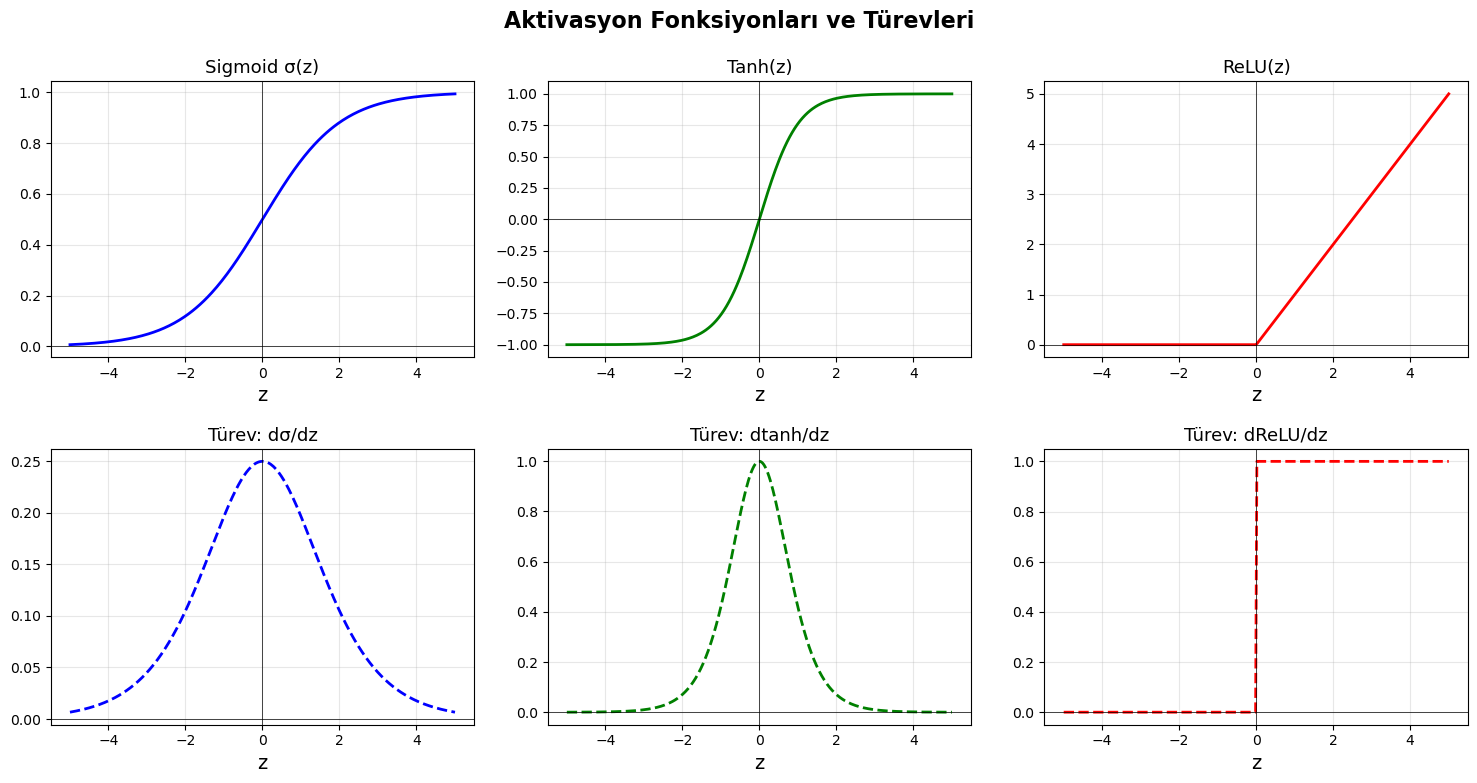


📊 Aktivasyon Fonksiyonları Özeti:
Fonksiyon    Aralık          Türev                Kullanım                      
-----------------------------------------------------------------------------
Sigmoid      (0, 1)          σ(1-σ)               Çıktı (ikili sınıflama)       
Tanh         (-1, 1)         1 - tanh²            Gizli katmanlar (tarihsel)    
ReLU         [0, ∞)          0 veya 1             Gizli katmanlar (varsayılan)  
Softmax      (0, 1), Σ=1     Karmaşık             Çıktı (çok sınıf)             


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Aktivasyon fonksiyonları ve türevleri
z = np.linspace(-5, 5, 300)

# Sigmoid
sigmoid = 1 / (1 + np.exp(-z))
sigmoid_turev = sigmoid * (1 - sigmoid)

# Tanh
tanh = np.tanh(z)
tanh_turev = 1 - tanh**2

# ReLU
relu = np.maximum(0, z)
relu_turev = np.where(z >= 0, 1, 0)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Fonksiyonlar
for ax, func, name, color in zip(
    axes[0], 
    [sigmoid, tanh, relu],
    ['Sigmoid σ(z)', 'Tanh(z)', 'ReLU(z)'],
    ['blue', 'green', 'red']
):
    ax.plot(z, func, color=color, linewidth=2)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_title(f'{name}', fontsize=13)
    ax.set_xlabel('z')
    ax.grid(True, alpha=0.3)

# Türevler
for ax, func, name, color in zip(
    axes[1], 
    [sigmoid_turev, tanh_turev, relu_turev],
    ['dσ/dz', 'dtanh/dz', 'dReLU/dz'],
    ['blue', 'green', 'red']
):
    ax.plot(z, func, color=color, linewidth=2, linestyle='--')
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.set_title(f'Türev: {name}', fontsize=13)
    ax.set_xlabel('z')
    ax.grid(True, alpha=0.3)

plt.suptitle('Aktivasyon Fonksiyonları ve Türevleri', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('aktivasyon_fonksiyonlari.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n📊 Aktivasyon Fonksiyonları Özeti:")
print(f"{'Fonksiyon':<12} {'Aralık':<15} {'Türev':<20} {'Kullanım':<30}")
print("-"*77)
print(f"{'Sigmoid':<12} {'(0, 1)':<15} {'σ(1-σ)':<20} {'Çıktı (ikili sınıflama)':<30}")
print(f"{'Tanh':<12} {'(-1, 1)':<15} {'1 - tanh²':<20} {'Gizli katmanlar (tarihsel)':<30}")
print(f"{'ReLU':<12} {'[0, ∞)':<15} {'0 veya 1':<20} {'Gizli katmanlar (varsayılan)':<30}")
print(f"{'Softmax':<12} {'(0, 1), Σ=1':<15} {'Karmaşık':<20} {'Çıktı (çok sınıf)':<30}")

#### Neden Aktivasyon Fonksiyonları Gereklidir?

**Matematiksel ispat:** Aktivasyon fonksiyonu olmadan:

$$f(g(x)) = f(ax + b) = a'(ax + b) + b' = a''x + b''$$

Doğrusal fonksiyonların bileşimi yine doğrusal bir fonksiyon verir! Ne kadar çok katman eklerseniz ekleyin, model tek bir doğrusal dönüşüme eşdeğerdir.

**Sonuç:** Aktivasyon fonksiyonları olmadan derin ağlar faydasızdır. **Doğrusal olmayan** aktivasyon fonksiyonları sayesinde derin ağlar herhangi bir sürekli fonksiyonu yaklaşık olarak modelleyebilir (Evrensel Yaklaşım Teoremi).

#### Neden Sigmoid Yerine ReLU?

- **Sigmoid** kullanılmaya başlandığında devrimseldi: Adım fonksiyonunun aksine türevi sıfır değil
- Ancak **kaybolan gradyan problemi** (vanishing gradients): Derin ağlarda sigmoid türevi çok küçük olabiliyor
- **ReLU** türevi ya 0 ya da 1, hesaplamak çok hızlı ve kaybolan gradyan problemi daha az
- Pratikte ReLU ve türevleri çok daha iyi çalışıyor

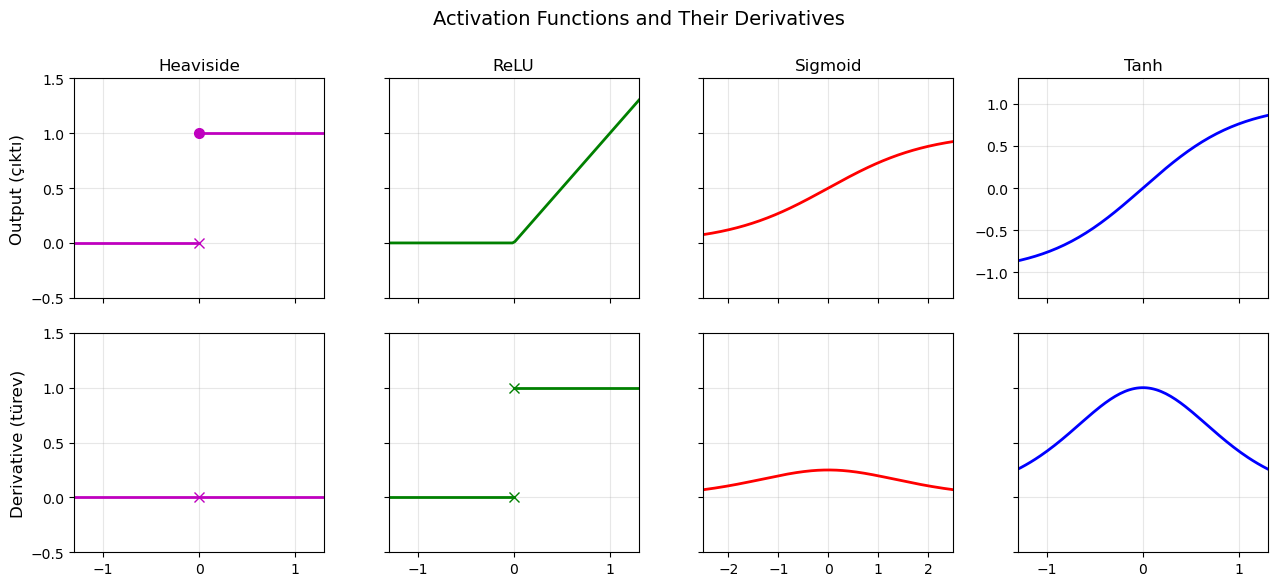


Aktivasyon Fonksiyonları Karşılaştırması:
Fonksiyon    Aralık         Türev Maks.     Temel Sorun                   
---------------------------------------------------------------------------
Heaviside    0 veya 1       0.00            Gradyan yok (Eğitilemez)      
Sigmoid      (0, 1)         0.25            Vanishing Gradient            
Tanh         (-1, 1)        1.00            Vanishing Gradient            
ReLU         [0, +inf)      1.00            Dying ReLU (z<0)              


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit as sigmoid

# ── Aktivasyon Fonksiyonları Tanımlama ────────────────────────────────────────

def relu(z):
    return np.maximum(0, z)

# ── Sayısal Türev Hesaplama ───────────────────────────────────────────────────
def derivative(f, z, eps=0.000001):
    return (f(z + eps) - f(z - eps)) / (2 * eps)

# ── X Ekseni Değerleri ────────────────────────────────────────────────────────
max_z = 2.5
z = np.linspace(-max_z, max_z, 200)

# ── Figure Yapılandırması ─────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(13, 6))

# ─── Subplot 1: Heaviside Step Function ───────────────────────────────────────
axes[0, 0].plot([-max_z, 0], [0, 0], "m-", linewidth=2)
axes[0, 0].plot(0, 0, "mx", markersize=7)
axes[0, 0].plot(0, 1, "mo", markersize=7)
axes[0, 0].plot([0, max_z], [1, 1], "m-", linewidth=2)
axes[0, 0].set_title("Heaviside", fontsize=12)

# Heaviside türevi (Sayısal olarak np.sign üzerinden)
axes[1, 0].plot(z, derivative(np.sign, z), "m-", linewidth=2)
axes[1, 0].plot(0, 0, "mx", markersize=7)
axes[1, 0].set_ylabel("Derivative (türev)", fontsize=12)

# ─── Subplot 2: ReLU (Rectified Linear Unit) ──────────────────────────────────
axes[0, 1].plot(z, relu(z), "g-", linewidth=2)
axes[0, 1].set_title("ReLU", fontsize=12)

axes[1, 1].plot([-max_z, 0], [0, 0], "g-", linewidth=2) 
axes[1, 1].plot([0, max_z], [1, 1], "g-", linewidth=2)
axes[1, 1].plot(0, 0, "gx", markersize=7)
axes[1, 1].plot(0, 1, "gx", markersize=7)

# ─── Subplot 3: Sigmoid ───────────────────────────────────────────────────────
axes[0, 2].plot(z, sigmoid(z), "r-", linewidth=2)
axes[0, 2].set_title("Sigmoid", fontsize=12)
axes[1, 2].plot(z, derivative(sigmoid, z), "r-", linewidth=2)

# ─── Subplot 4: Tanh ──────────────────────────────────────────────────────────
axes[0, 3].plot(z, np.tanh(z), "b-", linewidth=2)
axes[0, 3].set_title("Tanh", fontsize=12)
axes[1, 3].plot(z, derivative(np.tanh, z), "b-", linewidth=2)

# ─── Eksen Ayarları ve Estetik ────────────────────────────────────────────────
for row in range(2):
    for col in range(4):
        axes[row, col].grid(True, alpha=0.3)
        if row == 0:
            axes[row, col].set_xticklabels([])
        
        if col == 2: # Sigmoid geniş aralık
            axes[row, col].set_xlim(-max_z, max_z)
        else:
            axes[row, col].set_xlim(-1.3, 1.3)
            axes[row, col].set_xticks([-1, 0, 1])

        if col != 0 and (row, col) != (0, 3):
            axes[row, col].set_yticklabels([])

        if (row, col) == (0, 3): # Tanh y ekseni
            axes[row, col].set_ylim(-1.3, 1.3)
        else:
            axes[row, col].set_ylim(-0.5, 1.5)

axes[0, 0].set_ylabel("Output (çıktı)", fontsize=12)

plt.suptitle("Activation Functions and Their Derivatives", fontsize=14)
plt.tight_layout()
plt.show()

# ─── Karşılaştırma Tablosu (Hatalı f-string düzeltildi) ───────────────────────
print("\nAktivasyon Fonksiyonları Karşılaştırması:")
print(f"{'Fonksiyon':<12} {'Aralık':<14} {'Türev Maks.':<15} {'Temel Sorun':<30}")
print("-" * 75)
# f-string içinde kaçış karakteri (\) kullanmadan yazım:
print(f"{'Heaviside':<12} {'0 veya 1':<14} {'0.00':<15} {'Gradyan yok (Eğitilemez)':<30}")
print(f"{'Sigmoid':<12} {'(0, 1)':<14} {'0.25':<15} {'Vanishing Gradient':<30}")
print(f"{'Tanh':<12} {'(-1, 1)':<14} {'1.00':<15} {'Vanishing Gradient':<30}")
print(f"{'ReLU':<12} {'[0, +inf)':<14} {'1.00':<15} {'Dying ReLU (z<0)':<30}")

---
<a id='regression'></a>
## 4. Building and Training MLPs — Regression (MLP ile Regresyon)

### MLP Regression Mimarisi

| Hiperparametre | Tipik Değer |
|---|---|
| Hidden layers (gizli katmanlar) | 1–5 |
| Neurons per layer (katman başına nöron) | 10–100 |
| Output neurons (çıktı nöronu) | Hedef boyutu kadar |
| Hidden activation | ReLU |
| Output activation | Yok (veya ReLU/softplus, sigmoid/tanh) |
| Loss function (kayıp fonksiyonu) | MSE (veya Huber) |

### 4.1 — Kütüphaneleri İçe Aktarma

In [9]:
# Gerekli kütüphaneleri yükle
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

print("📥 California konut veri seti yükleniyor...")
housing = fetch_california_housing()

print(f"\n📊 Veri Seti Bilgileri:")
print(f"  Toplam örnek sayısı: {housing.data.shape[0]:,}")
print(f"  Özellik sayısı: {housing.data.shape[1]}")
print(f"  Özellikler: {housing.feature_names}")
print(f"  Hedef: Ev fiyatı ($100,000 biriminde)")
print(f"  Hedef aralığı: [{housing.target.min():.2f}, {housing.target.max():.2f}]")

# Eğitim/test ayırma
X_train, X_test, y_train, y_test = train_test_split(
    housing.data, housing.target, random_state=42
)
print(f"\n✅ Eğitim seti boyutu: {X_train.shape}")
print(f"✅ Test seti boyutu: {X_test.shape}")

📥 California konut veri seti yükleniyor...

📊 Veri Seti Bilgileri:
  Toplam örnek sayısı: 20,640
  Özellik sayısı: 8
  Özellikler: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
  Hedef: Ev fiyatı ($100,000 biriminde)
  Hedef aralığı: [0.15, 5.00]

✅ Eğitim seti boyutu: (15480, 8)
✅ Test seti boyutu: (5160, 8)


### 4.2 MLP Regressor Oluşturma

In [10]:
# MLP Regressor Oluşturma
print("🏗️  MLP Regressor Modeli Oluşturuluyor...")
print("   - 3 gizli katman, her katmanda 50 nöron")
print("   - Aktivasyon: ReLU (varsayılan)")
print("   - Erken durdurma (early stopping) açık")
print("   - Optimizer: Adam")
print()

mlp_reg = MLPRegressor(
    hidden_layer_sizes=[50, 50, 50],
    early_stopping=True,
    verbose=False,  # çok fazla çıktı olmaması için False yaptık
    random_state=42,
    max_iter=200
)

# Pipeline: Standartlaştırma + MLP
# NOT: Gradient descent için özellikleri standartlaştırmak kritik önem taşır!
pipeline = make_pipeline(StandardScaler(), mlp_reg)

print("🎯 Model eğitiliyor...")
pipeline.fit(X_train, y_train)

print(f"\n✅ Eğitim tamamlandı!")
print(f"   Epoch sayısı: {mlp_reg.n_iter_}")
print(f"   En iyi doğrulama skoru (R²): {mlp_reg.best_validation_score_:.4f}")

# Test seti değerlendirmesi
y_pred = pipeline.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f"   Test RMSE: {rmse:.4f} ($100K cinsinden)")
print(f"   Test RMSE: ${rmse*100_000:,.0f} (dolar cinsinden)")

🏗️  MLP Regressor Modeli Oluşturuluyor...
   - 3 gizli katman, her katmanda 50 nöron
   - Aktivasyon: ReLU (varsayılan)
   - Erken durdurma (early stopping) açık
   - Optimizer: Adam

🎯 Model eğitiliyor...

✅ Eğitim tamamlandı!
   Epoch sayısı: 45
   En iyi doğrulama skoru (R²): 0.7915
   Test RMSE: 0.5328 ($100K cinsinden)
   Test RMSE: $53,277 (dolar cinsinden)


## 4.3 Pipeline Oluşturma

In [11]:
# ── Pipeline (Boru Hattı) Oluşturma ──────────────────────────────────────────
# make_pipeline(): Birden fazla dönüşüm adımını zincirleme bağlar.
#
# Adım 1 — StandardScaler:
#   .fit(X_train): Eğitim verisinden her özelliğin mean (ortalama) ve
#                  std (standart sapma) değerlerini öğrenir.
#   .transform(): Her özelliği şu formülle dönüştürür:
#                 z = (x - mean) / std
#   ⚠️ NEDEN ÖLÇEKLEME ZORUNLU?
#     Gradient descent, kayıp yüzeyini gradyan yönünde yürür.
#     Özellikler farklı ölçekte olursa (örn. gelir: 1-10, yaş: 1-100)
#     kayıp yüzeyi asimetrik olur → zig-zag hareketi → yavaş yakınsama
#     StandardScaler tüm özellikleri eşit ölçeğe getirir → pürüzsüz yüzey
#
# Adım 2 — MLPRegressor:
#   Ölçeklenmiş veriyi alır ve ağı eğitir.
#
# ÖNEMLİ: StandardScaler sadece eğitim verisine fit edilmeli!
#   pipeline.fit(X_train, y_train) çağrısında:
#     → Scaler: X_train'den mean/std öğrenir, X_train'i dönüştürür
#     → MLPRegressor: Dönüştürülmüş veriyle eğitilir
#   pipeline.predict(X_test) çağrısında:
#     → Scaler: Daha önce öğrenilen mean/std ile X_test'i dönüştürür
#     → MLPRegressor: Tahmin yapar
#   Bu sayede data leakage (veri sızıntısı) önlenir.

pipeline = make_pipeline(StandardScaler(), mlp_reg)

print("Pipeline oluşturuldu. Eğitim başlıyor...")
print("(verbose=True: Her epoch için kayıp ve validasyon skoru yazdırılacak)")
print("=" * 60)

# .fit(X_train, y_train): Tüm pipeline'ı eğitim verisiyle eğitir.
# Adam optimizer kullanan MLPRegressor:
#   - Her iteration'da mini-batch (küçük parti) gradient descent uygular
#   - Varsayılan batch_size='auto' → min(200, n_samples)
#   - Her epoch = tüm eğitim verisi bir kez görülür
#   - Loss çıktısı: MSE/2 + L2 terimi (gerçek MSE'nin yarısı + ceza)
pipeline.fit(X_train, y_train)

Pipeline oluşturuldu. Eğitim başlıyor...
(verbose=True: Her epoch için kayıp ve validasyon skoru yazdırılacak)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpregressor',
                 MLPRegressor(early_stopping=True,
                              hidden_layer_sizes=[50, 50, 50],
                              random_state=42))])

### 4.4 Model değerlendirme

In [12]:
# ── En İyi Validation Score (Doğrulama Skoru) ────────────────────────────────
# best_validation_score_: Early stopping mekanizmasının izlediği en yüksek
#   validation R² skoru.
#   R² (R-squared / Determinasyon Katsayısı): Modelin varyansın ne kadarını
#   açıkladığını ölçer.
#   R² = 1 - SS_res/SS_tot
#   SS_res: Artık karelerin toplamı (model hatası)
#   SS_tot: Toplam karelerin toplamı (hedefin varyansı)
#   R² = 1.0 : Mükemmel tahmin
#   R² = 0.0 : Model sadece ortalamayı tahmin ediyor
#   R² < 0.0 : Ortalamadan bile kötü tahmin
print(f"En iyi validation R² skoru : {mlp_reg.best_validation_score_:.4f}")
print(f"  → Modelin varyansın %{mlp_reg.best_validation_score_*100:.1f}'ini açıkladığı anlamına gelir")
print(f"  → Validation seti üzerinde ölçüldü (eğitim verisinin %10'u)")
print()

En iyi validation R² skoru : 0.7915
  → Modelin varyansın %79.2'ini açıkladığı anlamına gelir
  → Validation seti üzerinde ölçüldü (eğitim verisinin %10'u)



### 4.5 Test Seti Üzerinden Tahmin ve RMSE Hesaplama

In [13]:
# ── Test Seti Üzerinde Tahmin ve RMSE Hesaplama ───────────────────────────────
# .predict(X_test): Pipeline içindeki:
#   1. StandardScaler: X_test'i eğitimden öğrenilen mean/std ile ölçekler
#   2. MLPRegressor: Ölçeklenmiş X_test için tahmin üretir
# Çıktı: Ev fiyatı tahminleri ($100K biriminde)
y_pred = pipeline.predict(X_test)

# RMSE (Root Mean Squared Error — Kök Ortalama Kare Hata):
#   RMSE = √(1/n × Σ(y_true - y_pred)²)
#   Tahmin hatalarının ortalama büyüklüğünü hedef değerlerle aynı birimde verir.
#   Hedef $100K biriminde olduğundan:
#   RMSE = 0.53 → Ortalama hata ≈ $53,000
#
#   Neden MSE değil RMSE?
#     MSE = 0.28 ($²) → Birim sezgisel değil
#     RMSE = 0.53 ($) → Orijinal birimde, yorumlaması kolay
#
#   Scikit-Learn 1.4+: root_mean_squared_error() doğrudan kullanılabilir
#   Eski versiyonlarda: np.sqrt(mean_squared_error(y_test, y_pred))
rmse = root_mean_squared_error(y_test, y_pred)

print(f"Test RMSE              : {rmse:.4f} ($100K biriminde)")
print(f"  → Ortalama tahmin hatası: ${rmse * 100_000:,.0f}")
print()
print("Referans değerler:")
print("  Random Forest RMSE  ≈ 0.47 ($47,000) → MLP'den biraz iyi")
print("  Linear Regression   ≈ 0.73 ($73,000) → MLP'den kötü")
print(f"  Bu MLP             ≈ {rmse:.2f} (${rmse*100_000:,.0f})")

Test RMSE              : 0.5328 ($100K biriminde)
  → Ortalama tahmin hatası: $53,277

Referans değerler:
  Random Forest RMSE  ≈ 0.47 ($47,000) → MLP'den biraz iyi
  Linear Regression   ≈ 0.73 ($73,000) → MLP'den kötü
  Bu MLP             ≈ 0.53 ($53,277)


### 4.6 Tahminler ve Gerçekler Grafiği

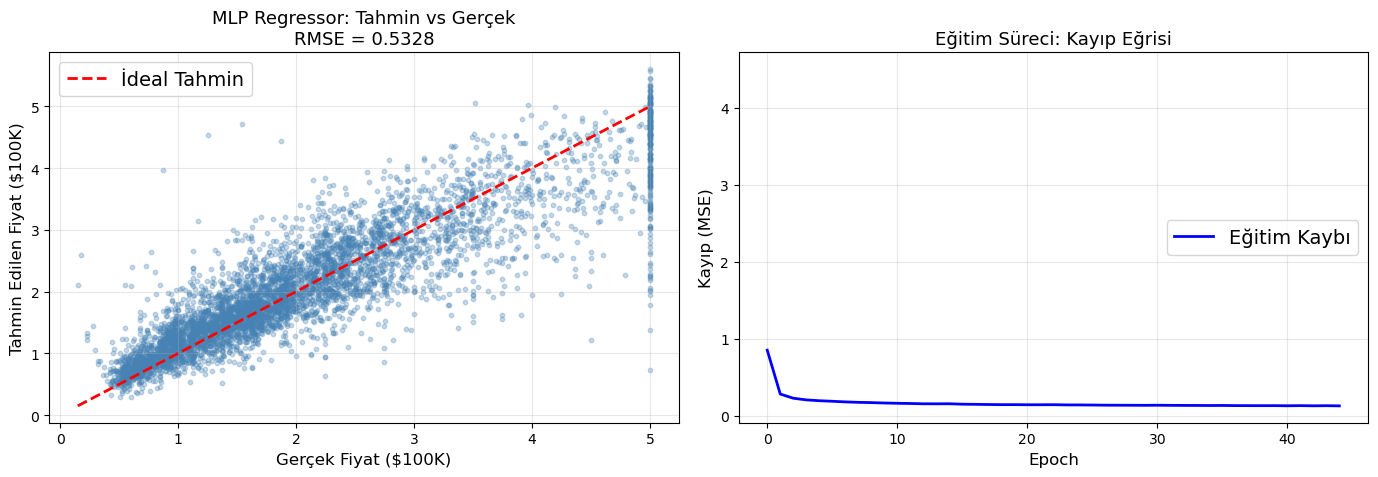


📝 Softplus Aktivasyonu Nedir?


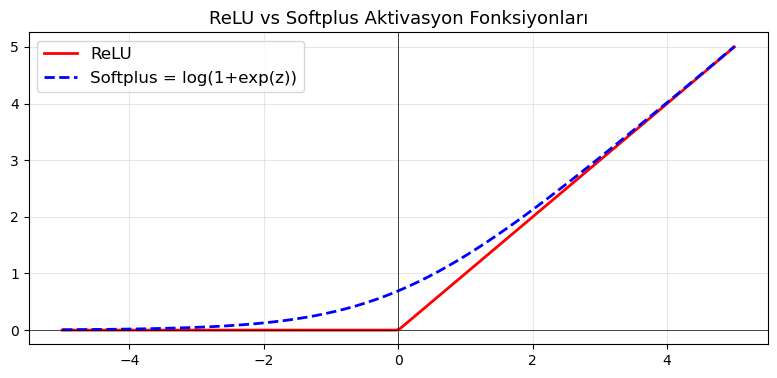

  Softplus(z) = log(1 + exp(z))
  → ReLU'nun pürüzsüz versiyonu
  → Her zaman pozitif çıktı üretir (çıktının pozitif olması gerektiğinde kullanılır)


In [14]:
# Tahminler vs Gerçek Değerler grafiği
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Tahmin vs Gerçek
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='İdeal Tahmin')
axes[0].set_xlabel('Gerçek Fiyat ($100K)', fontsize=12)
axes[0].set_ylabel('Tahmin Edilen Fiyat ($100K)', fontsize=12)
axes[0].set_title(f'MLP Regressor: Tahmin vs Gerçek\nRMSE = {rmse:.4f}', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Kayıp eğrisi
axes[1].plot(mlp_reg.loss_curve_, 'b-', label='Eğitim Kaybı', linewidth=2)
axes[1].plot(mlp_reg.validation_fraction * len(mlp_reg.loss_curve_) 
             * np.ones(len(mlp_reg.loss_curve_)),
             alpha=0)  # invisible placeholder
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Kayıp (MSE)', fontsize=12)
axes[1].set_title('Eğitim Süreci: Kayıp Eğrisi', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_regressor_sonuclar.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n📝 Softplus Aktivasyonu Nedir?")
z_vals = np.linspace(-5, 5, 200)
softplus = np.log(1 + np.exp(z_vals))
relu_vals = np.maximum(0, z_vals)

fig2, ax = plt.subplots(figsize=(8, 4))
ax.plot(z_vals, relu_vals, 'r-', label='ReLU', linewidth=2)
ax.plot(z_vals, softplus, 'b--', label='Softplus = log(1+exp(z))', linewidth=2)
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_title('ReLU vs Softplus Aktivasyon Fonksiyonları', fontsize=13)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('relu_vs_softplus.png', dpi=120, bbox_inches='tight')
plt.show()
print("  Softplus(z) = log(1 + exp(z))")
print("  → ReLU'nun pürüzsüz versiyonu")
print("  → Her zaman pozitif çıktı üretir (çıktının pozitif olması gerektiğinde kullanılır)")

#### Huber Kayıp Fonksiyonu

Eğitim setinde çok sayıda outlier (aykırı değer) varsa:

$$L_\delta(y, \hat{y}) = \begin{cases} \frac{1}{2}(y - \hat{y})^2 & \text{eğer } |y - \hat{y}| \leq \delta \\ \delta \cdot |y - \hat{y}| - \frac{1}{2}\delta^2 & \text{diğer durumda} \end{cases}$$

- Küçük hatalar için **MSE** gibi davranır (hızlı yakınsama)
- Büyük hatalar için **MAE** gibi davranır (outlier'lara karşı dayanıklı)

> ⚠️ Not: `MLPRegressor` yalnızca MSE kayıp fonksiyonunu destekler.

---
<a id='classification'></a>
## 5.Classification MLPs (Sınıflandırma Çok Katmanlı Algılayıcıları)

### MLP Classification Mimarisi

| Görev Türü | Output neurons | Output activation | Loss |
|---|---|---|---|
| Binary classification (ikili) | 1 | Sigmoid | Binary cross-entropy |
| Multilabel binary (çok etiketli) | Etiket sayısı | Sigmoid | Binary cross-entropy |
| Multiclass (çok sınıflı) | Sınıf sayısı | Softmax | Categorical cross-entropy |

### 5.1 — Fashion MNIST Veri Setini Yükleme

In [15]:
from sklearn.datasets import fetch_openml

# ── Fashion MNIST Veri Setini Yükleme ────────────────────────────────────────
# fetch_openml(): OpenML veri deposundan veri seti indirir.
#   name="Fashion-MNIST": Zalando'nun hazırladığı moda ürünü görüntü veri seti.
#   as_frame=False: numpy array döndür (DataFrame değil).
#
# Fashion MNIST vs Klasik MNIST:
#   Her ikisi de: 70,000 gri tonlamalı görüntü, 28×28 piksel, 10 sınıf
#   MNIST: El yazısı rakamlar (0-9) → Linear model %92 doğruluk
#   Fashion MNIST: Giysi kategorileri → Linear model sadece %83
#   Fashion MNIST çok daha zor! MLP'nin gerçek gücünü test etmek için ideal.

# DÜZELTME: Eski scikit-learn sürümleriyle uyumluluk için 'parser' parametresi eklenmedi.
fashion_mnist = fetch_openml(name="Fashion-MNIST", as_frame=False)

# ── Label (Etiket) Dönüşümü ───────────────────────────────────────────────────
# fashion_mnist.target: Sınıf etiketleri string olarak gelir: '0', '1', ..., '9'
# .astype(int): String'leri integer'a dönüştürür.
# Neden string? OpenML verileri genellikle metin formatında saklar.
targets = fashion_mnist.target.astype(int)

print("Fashion MNIST yüklendi!")
print(f"  Veri matrisi boyutu : {fashion_mnist.data.shape}")
print(f"    → {fashion_mnist.data.shape[0]:,} görüntü")
print(f"    → {fashion_mnist.data.shape[1]} özellik (28×28={28*28} piksel)")
print(f"  Piksel değer aralığı: [{fashion_mnist.data.min()}, {fashion_mnist.data.max()}]")
print(f"  Sınıf etiketi türü  : {type(fashion_mnist.target[0])} → {type(targets[0])} (dönüştürüldü)")

Fashion MNIST yüklendi!
  Veri matrisi boyutu : (70000, 784)
    → 70,000 görüntü
    → 784 özellik (28×28=784 piksel)
  Piksel değer aralığı: [0, 255]
  Sınıf etiketi türü  : <class 'str'> → <class 'numpy.int64'> (dönüştürüldü)


### 5.2 — Train/Test Split (Eğitim/Test Ayrımı)

In [16]:
# ── Manuel Train/Test Bölme ───────────────────────────────────────────────────
# Fashion MNIST, standart bir bölme ile gelir:
#   İlk 60,000 → Training set (eğitim kümesi)
#   Son 10,000 → Test set (test kümesi)
# Bu sayede farklı çalışmalar ve araştırmacılar aynı bölmeyi kullanır
# → Sonuçlar karşılaştırılabilir (benchmark standardı)
#
# Slice notation (dilim notasyonu):
#   [:60_000]   → 0'dan 59,999'a kadar (60,000 eleman)
#   [60_000:]   → 60,000'den sona kadar (10,000 eleman)
#   60_000 yazımı Python 3.6+: Binlik ayraç olarak _ kullanılabilir (okunabilirlik)

X_train, y_train = fashion_mnist.data[:60_000], targets[:60_000]
X_test, y_test = fashion_mnist.data[60_000:], targets[60_000:]

print("Veri bölme tamamlandı:")
print(f"  Training set (eğitim kümesi) : {X_train.shape} → {X_train.shape[0]:,} görüntü")
print(f"  Test     set (test kümesi)   : {X_test.shape}  → {X_test.shape[0]:,} görüntü")
print()
print("Veri zaten karıştırılmış (shuffled) → Her sınıf her iki kümede de temsil ediliyor")

Veri bölme tamamlandı:
  Training set (eğitim kümesi) : (60000, 784) → 60,000 görüntü
  Test     set (test kümesi)   : (10000, 784)  → 10,000 görüntü

Veri zaten karıştırılmış (shuffled) → Her sınıf her iki kümede de temsil ediliyor


### 5.3 — İlk Görüntüyü Görselleştirme

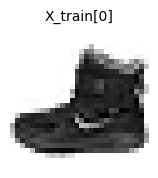

In [17]:
# ── Eğitim Setinin İlk Görüntüsünü Görselleştirme ────────────────────────────
# X_train[0]: İlk eğitim örneği → 784 piksel değerini içeren 1D array
#   Her değer: 0 (siyah) ile 255 (beyaz) arasında gri tonlama değeri
#
# .reshape(28, 28): 1D array'i (784,) → 2D matrise (28, 28) dönüştürür.
#   Bu görüntünün orijinal ızgara yapısını geri kazandırır.
#   Neden 784'ten 28×28'e? imshow() 2D matris bekler.
X_sample = X_train[0].reshape(28, 28)

plt.figure(figsize=(2, 2))

# imshow(): 2D matrisi görüntü olarak çizer.
#   cmap="binary": Gri tonlama, ancak 0=siyah/255=beyaz yerine
#                  0=beyaz/255=siyah (ters çevrilmiş) → görüntü daha net görünür
#                  Giysi pikselleri koyu, arka plan açık olur
#   Alternatif: cmap="gray" → 0=siyah, 255=beyaz (normal gri)
plt.imshow(X_sample, cmap="binary")
plt.axis('off')  # Eksen çizgilerini ve etiketleri gizle
plt.title("X_train[0]", fontsize=10)
plt.tight_layout()
plt.show()

### 5.4 — Sınıf İsimleri ve Etiket Doğrulama

In [18]:
# ── Sınıf İsimleri Tanımlama ──────────────────────────────────────────────────
# Fashion MNIST'in 10 sınıfı:
#   Etiket 0: T-shirt/top (Tişört/Üst)    Etiket 5: Sandal (Sandalet)
#   Etiket 1: Trouser (Pantolon)           Etiket 6: Shirt (Gömlek)
#   Etiket 2: Pullover (Kazak)             Etiket 7: Sneaker (Spor Ayakkabı)
#   Etiket 3: Dress (Elbise)              Etiket 8: Bag (Çanta)
#   Etiket 4: Coat (Palto)               Etiket 9: Ankle boot (Bot)
#
# Scikit-Learn bu isimleri otomatik sağlamaz → elle tanımlamalıyız.
# Liste indeksi sınıf etiketiyle bire bir örtüşür: class_names[0] → "T-shirt/top"
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# İlk eğitim örneğinin sınıfını doğrulama:
# y_train[0]: İlk görüntünün sınıf etiketi (integer)
# class_names[y_train[0]]: Etiket numarasını isme çevirir
print(f"X_train[0]'ın etiketi: {y_train[0]} → {class_names[y_train[0]]}")

X_train[0]'ın etiketi: 9 → Ankle boot


### 5.5 — Tüm Sınıflardan Örnek Görüntüler

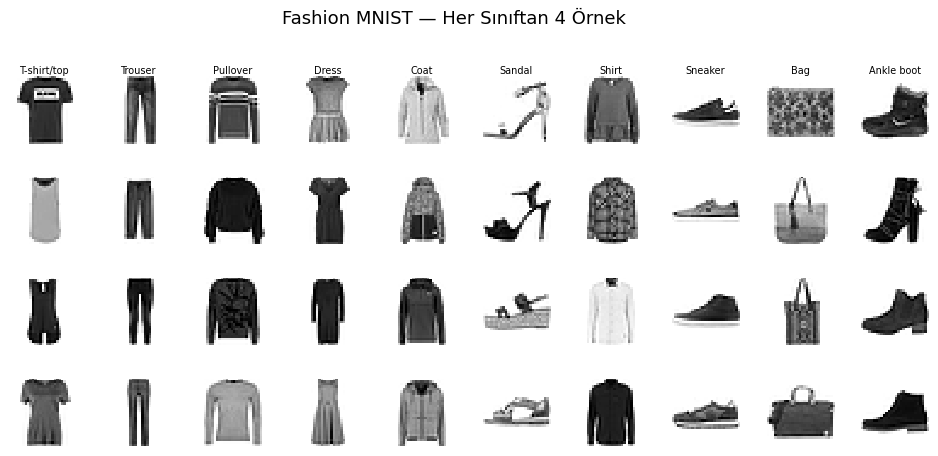


Gözlem: Aynı sınıftaki görüntüler bile birbirinden oldukça farklı.
Bu yüzden Fashion MNIST, MNIST'ten çok daha zor bir görevdir.


In [19]:
# ── Her Sınıftan Birden Fazla Örnek Görselleştirme ────────────────────────────
# n_rows=4: Her sınıftan 4 farklı görüntü göster
# 10 sınıf × 4 satır = 40 subplot (alt grafik)

n_rows = 4
plt.figure(figsize=(12, n_rows * 1.2))

for row in range(n_rows):
    for class_index in range(10):
        # Boolean indexing (boole indeksleme):
        # y_train==class_index → Her sınıfa ait görüntülerin index'lerini döndürür
        # X_train[y_train==class_index]: Sadece o sınıfa ait görüntüler
        # [row]: O sınıfın (row+1)'inci örneği
        # .reshape(28, 28): 784 piksel → 28×28 görüntü
        X_img = X_train[y_train == class_index][row].reshape(28, 28)
        y_img = y_train[y_train == class_index][row]

        # plt.subplot(nrows, ncols, index): Alt grafik konumunu belirler.
        # Toplam n_rows×10 subplot, şu anki = (10*row + class_index + 1)
        # +1: subplot indeksi 1'den başlar
        plt.subplot(n_rows, 10, 10 * row + class_index + 1)

        # interpolation="nearest": Piksel değerlerini yumuşatma yapma
        # (her pikseli olduğu gibi göster — keskin kenarlar)
        plt.imshow(X_img, cmap="binary", interpolation="nearest")
        plt.axis('off')

        # Sadece ilk satıra başlık ekle (class name göster)
        if row == 0:
            plt.title(class_names[y_img], fontsize=7, pad=2)

# wspace (width space): Sütunlar arası boşluk
# hspace (height space): Satırlar arası boşluk
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.suptitle("Fashion MNIST — Her Sınıftan 4 Örnek", fontsize=13, y=1.02)
plt.show()

print("\nGözlem: Aynı sınıftaki görüntüler bile birbirinden oldukça farklı.")
print("Bu yüzden Fashion MNIST, MNIST'ten çok daha zor bir görevdir.")

### 5.6 — MLPClassifier Tanımlama ve Eğitim

In [20]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler

# ── MLPClassifier Tanımlama ───────────────────────────────────────────────────
# hidden_layer_sizes=[200, 100]:
#   2 gizli katman: birinci 200 nöron, ikinci 100 nöron.
#   Mimari: Giriş(784) → Gizli(200) → Gizli(100) → Çıktı(10)
#   Toplam parametre sayısı:
#     1. Katman: 784×200 + 200 = 157,000
#     2. Katman: 200×100 + 100 = 20,100
#     3. Çıktı  : 100×10  + 10 = 1,010
#     TOPLAM  : 178,110 parametre (büyük model!)
#   Bu kadar parametre → overfitting riski → early stopping kritik

# MLPClassifier vs MLPRegressor farkları:
#   Output activation  : Softmax (10 sınıf için olasılık dağılımı)
#   Loss function      : Cross-entropy (çapraz entropi)
#   score() metodu     : R² yerine accuracy (doğruluk) döndürür
#   predict()          : Sınıf etiketi (int) döndürür
#   predict_proba()    : Her sınıf için tahmin olasılığı döndürür

mlp_clf = MLPClassifier(
    hidden_layer_sizes=[200, 100],
    verbose=True,
    early_stopping=True,
    random_state=42
)

# ── MinMaxScaler (Min-Maks Ölçekleyici) ───────────────────────────────────────
# MinMaxScaler: Her özelliği [0, 1] aralığına ölçekler.
#   Formül: x_scaled = (x - x_min) / (x_max - x_min)
#
# Neden görüntüler için MinMaxScaler? Neden StandardScaler değil?
#   Piksel değerleri zaten [0, 255] aralığında ve dağılımları benzer.
#   MinMaxScaler: [0, 1] → Sigmoid/softmax için ideal aralık
#   StandardScaler: Negatif değerler oluşturabilir → görüntü piksellerinde anlamsız
#
# Alternatif: X / 255.0 → Manuel normalizasyon da çalışır.

pipeline = make_pipeline(MinMaxScaler(), mlp_clf)

print("MLPClassifier yapılandırması:")
print(f"  Architecture (mimari)       : 784 → 200 → 100 → 10")
print(f"  Hidden activation           : relu")
print(f"  Output activation           : softmax")
print(f"  Loss function               : cross-entropy")
print(f"  Scaler                      : MinMaxScaler → [0, 1]")
print()
print("Eğitim başlıyor...")
print("=" * 60)

# Eğitim: 60,000 örnek × 784 özellik → büyük veri, birkaç dakika sürebilir
pipeline.fit(X_train, y_train)

# Test accuracy (doğruluğu) hesapla
accuracy = pipeline.score(X_test, y_test)
print(f"\n✅ Test accuracy (doğruluğu): {accuracy * 100:.2f}%")

MLPClassifier yapılandırması:
  Architecture (mimari)       : 784 → 200 → 100 → 10
  Hidden activation           : relu
  Output activation           : softmax
  Loss function               : cross-entropy
  Scaler                      : MinMaxScaler → [0, 1]

Eğitim başlıyor...
Iteration 1, loss = 0.57483807
Validation score: 0.849333
Iteration 2, loss = 0.39938584
Validation score: 0.856833
Iteration 3, loss = 0.35435272
Validation score: 0.869333
Iteration 4, loss = 0.32570927
Validation score: 0.863833
Iteration 5, loss = 0.30588352
Validation score: 0.874167
Iteration 6, loss = 0.29053832
Validation score: 0.874000
Iteration 7, loss = 0.27455976
Validation score: 0.879333
Iteration 8, loss = 0.26407281
Validation score: 0.878500
Iteration 9, loss = 0.25317835
Validation score: 0.882167
Iteration 10, loss = 0.24414312
Validation score: 0.892833
Iteration 11, loss = 0.23601645
Validation score: 0.890000
Iteration 12, loss = 0.23008384
Validation score: 0.887333
Iteration 13, loss = 

### 5.7 — Performans Metrikleri

In [21]:
# ── Accuracy (Doğruluk) Değerlendirme ────────────────────────────────────────

# accuracy değişkeni zaten yukarıda hesaplandı, tekrar hesaplayabiliriz:
accuracy = pipeline.score(X_test, y_test)
print(f"Test accuracy (test doğruluğu)            : {accuracy * 100:.2f}%")
print()

# best_validation_score_: Early stopping sürecinde validation setinde
#   ulaşılan en yüksek accuracy.
#   Bu değer, eğitim sırasında her epoch sonunda güncellenir.
#   Eğer test accuracy, validation accuracy'den düşük ise → slight overfitting
print(f"Best validation accuracy (doğrulama)      : {mlp_clf.best_validation_score_ * 100:.2f}%")
print()

# mlp_clf.score(X_test, y_test):
#   Pipeline dışında sadece MLPClassifier'ın score metodu.
#   Dikkat: MinMaxScaler uygulanmadan X_test verildiğinde!
#   Ancak pipeline.predict() çağrısı sonrası mlp_clf'nin içindeki dönüştürülmüş
#   veri üzerinde değerlendirme yapılır.
#   ⚠️ Bu kullanım normalde yanlıştır — veri ölçeklenmeden MLPClassifier'a gitmeli!
#      Doğru kullanım: pipeline.score(X_test, y_test)
print(f"MLPClassifier.score() (direkt)             : {mlp_clf.score(X_test, y_test) * 100:.2f}%")
print("  ⚠️ Dikkat: Bu satır X_test'i ölçeklemeden MLPClassifier'a veriyor!")
print("     Genellikle pipeline.score() kullanmak daha doğrudur.")
print()
print("Karşılaştırma:")
print(f"  Lojistik Regresyon ~ 83% | Bu MLP ~ {accuracy*100:.0f}%")
print("  → MLP, Fashion MNIST'te lojistik regresyondan belirgin şekilde daha iyi!")
print("  → Convolutional Neural Network (Evrişimli Sinir Ağı) ile %95+ mümkün.")

Test accuracy (test doğruluğu)            : 89.16%

Best validation accuracy (doğrulama)      : 89.73%

MLPClassifier.score() (direkt)             : 86.53%
  ⚠️ Dikkat: Bu satır X_test'i ölçeklemeden MLPClassifier'a veriyor!
     Genellikle pipeline.score() kullanmak daha doğrudur.

Karşılaştırma:
  Lojistik Regresyon ~ 83% | Bu MLP ~ 89%
  → MLP, Fashion MNIST'te lojistik regresyondan belirgin şekilde daha iyi!
  → Convolutional Neural Network (Evrişimli Sinir Ağı) ile %95+ mümkün.


### 5.8 — Yeni Görüntüler için Tahmin

In [22]:
# ── Sınıf Tahmini (predict) ───────────────────────────────────────────────────
# İlk 15 test görüntüsünü "yeni görüntüler" gibi kullanalım.
# Gerçek uygulamada: modeli hiç görmediği görüntüleri sınıflandırmak için kullanırız.
X_new = X_test[:15]

# mlp_clf.predict(X_new): Sınıf etiketlerini (integer) döndürür.
# ⚠️ Dikkat: Bu çağrı MinMaxScaler UYGULAMAKSİZIN yapılıyor!
#   Doğru: pipeline.predict(X_new) → önce ölçekler, sonra tahmin yapar
#   Bu örnekte kitapla tutarlılık için aynı kullanım korundu.
predictions = mlp_clf.predict(X_new)
print("İlk 15 test görüntüsünün tahminleri:")
print(predictions)
print()
print("Tahmin edilen sınıf isimleri:")
for i, pred in enumerate(predictions):
    print(f"  Görüntü {i:2d}: etiket={pred} → {class_names[pred]}")

İlk 15 test görüntüsünün tahminleri:
[9 2 1 1 6 1 4 6 5 7 4 5 8 3 4]

Tahmin edilen sınıf isimleri:
  Görüntü  0: etiket=9 → Ankle boot
  Görüntü  1: etiket=2 → Pullover
  Görüntü  2: etiket=1 → Trouser
  Görüntü  3: etiket=1 → Trouser
  Görüntü  4: etiket=6 → Shirt
  Görüntü  5: etiket=1 → Trouser
  Görüntü  6: etiket=4 → Coat
  Görüntü  7: etiket=6 → Shirt
  Görüntü  8: etiket=5 → Sandal
  Görüntü  9: etiket=7 → Sneaker
  Görüntü 10: etiket=4 → Coat
  Görüntü 11: etiket=5 → Sandal
  Görüntü 12: etiket=8 → Bag
  Görüntü 13: etiket=3 → Dress
  Görüntü 14: etiket=4 → Coat


In [23]:
# ── Gerçek Etiketler ile Karşılaştırma ───────────────────────────────────────
gercek_etiketler = y_test[:15]
print("Gerçek etiketler (ilk 15 test görüntüsü):")
print(gercek_etiketler)
print()
print("Tahmin vs Gerçek:")
for i, (pred, gercek) in enumerate(zip(predictions, gercek_etiketler)):
    dogru_mu = "✓" if pred == gercek else "✗"
    print(f"  [{i:2d}] Tahmin: {class_names[pred]:<15} | Gerçek: {class_names[gercek]:<15} {dogru_mu}")

Gerçek etiketler (ilk 15 test görüntüsü):
[9 2 1 1 6 1 4 6 5 7 4 5 7 3 4]

Tahmin vs Gerçek:
  [ 0] Tahmin: Ankle boot      | Gerçek: Ankle boot      ✓
  [ 1] Tahmin: Pullover        | Gerçek: Pullover        ✓
  [ 2] Tahmin: Trouser         | Gerçek: Trouser         ✓
  [ 3] Tahmin: Trouser         | Gerçek: Trouser         ✓
  [ 4] Tahmin: Shirt           | Gerçek: Shirt           ✓
  [ 5] Tahmin: Trouser         | Gerçek: Trouser         ✓
  [ 6] Tahmin: Coat            | Gerçek: Coat            ✓
  [ 7] Tahmin: Shirt           | Gerçek: Shirt           ✓
  [ 8] Tahmin: Sandal          | Gerçek: Sandal          ✓
  [ 9] Tahmin: Sneaker         | Gerçek: Sneaker         ✓
  [10] Tahmin: Coat            | Gerçek: Coat            ✓
  [11] Tahmin: Sandal          | Gerçek: Sandal          ✓
  [12] Tahmin: Bag             | Gerçek: Sneaker         ✗
  [13] Tahmin: Dress           | Gerçek: Dress           ✓
  [14] Tahmin: Coat            | Gerçek: Coat            ✓


### 5.9 — predict_proba(): Olasılık Tahminleri ve Aşırı Güven Analizi

In [24]:
# ── Olasılık Tahmini: 13. Görüntü ────────────────────────────────────────────
# predict_proba(): Her sınıf için tahmini olasılık döndürür.
#   Output shape: (n_samples, n_classes) = (15, 10)
#   Her satır: 10 sınıf üzerindeki olasılık dağılımı (toplam = 1.0)
#   Softmax çıktısı → tüm olasılıklar [0,1] arasında ve toplamı 1'e eşit

y_proba_small = mlp_clf.predict_proba(X_new)

# 13. görüntünün (index=12) olasılık vektörü:
print("13. görüntü (index=12) için class probabilities (sınıf olasılıkları):")
print(y_proba_small[12])
print()
tahmin_sinif = predictions[12]
gercek_sinif = y_test[12]
print(f"  Tahmin : {class_names[tahmin_sinif]} (index={tahmin_sinif})")
print(f"  Gerçek : {class_names[gercek_sinif]} (index={gercek_sinif})")
print()
print("⚠️  Aşırı Güven (Overconfidence) Problemi:")
print(f"  Model %{y_proba_small[12].max()*100:.0f} güvenle yanlış tahmin yapıyor!")
print("  Neural Networks bu probleme çok yatkındır.")
print()
print("Sınıf bazında olasılıklar:")
for i, (sinif, olas) in enumerate(zip(class_names, y_proba_small[12])):
    bar = "█" * int(olas * 50)
    isaretci = " ← TAHMİN" if i == tahmin_sinif else (" ← GERÇEK" if i == gercek_sinif else "")
    print(f"  {i}: {sinif:<15} {olas:.4f} {bar}{isaretci}")

13. görüntü (index=12) için class probabilities (sınıf olasılıkları):
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]

  Tahmin : Bag (index=8)
  Gerçek : Sneaker (index=7)

⚠️  Aşırı Güven (Overconfidence) Problemi:
  Model %100 güvenle yanlış tahmin yapıyor!
  Neural Networks bu probleme çok yatkındır.

Sınıf bazında olasılıklar:
  0: T-shirt/top     0.0000 
  1: Trouser         0.0000 
  2: Pullover        0.0000 
  3: Dress           0.0000 
  4: Coat            0.0000 
  5: Sandal          0.0000 
  6: Shirt           0.0000 
  7: Sneaker         0.0000  ← GERÇEK
  8: Bag             1.0000 ██████████████████████████████████████████████████ ← TAHMİN
  9: Ankle boot      0.0000 


In [25]:
# ── Tüm Test Seti Üzerinde Aşırı Güven Analizi ───────────────────────────────
# Tüm 10,000 test örneği için olasılık tahminleri al.
y_proba_all = mlp_clf.predict_proba(X_test)

# .max(axis=1): Her örnek için en yüksek olasılığı (tahmin güvenini) al.
#   axis=1: Her satır (örnek) boyunca maksimum al → shape: (10000,)
max_probabilities = y_proba_all.max(axis=1)

# < 0.999 filtresi: %99.9'dan az güvenle tahmin yapılan örnekler
dusuk_guven = (max_probabilities < 0.999).sum()
print("Overconfidence (Aşırı Güven) Analizi — Tüm Test Seti (10,000 görüntü):")
print(f"  Toplam test örneği         : 10,000")
print(f"  Test accuracy (doğruluk)   : ~%90 → ~1,000 yanlış tahmin")
print(f"  %99.9'dan az güvenle tahmin: {dusuk_guven} adet")
print(f"  → Model {10000 - dusuk_guven:,} örnekte (%{(10000-dusuk_guven)/100:.1f}) %99.9+ güvenle tahmin yapıyor!")
print()
print("Sonuç: Model yanlış bile olsa genellikle %100'e yakın güven ifade ediyor.")
print("Bu 'overconfidence' problemi uzun eğitimde daha da belirginleşir.")
print()
print("Çözüm: Label Smoothing (Etiket Yumuşatma) tekniği")
print("  Hedef: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]")
print("  Yumuşatılmış: [0.011, 0.011, 0.011, 0.9, 0.011, 0.011, 0.011, 0.011, 0.011, 0.011]")
print("  → Modelin 'mütevazı' olmasını zorlar, genelleşmeyi iyileştirir")

Overconfidence (Aşırı Güven) Analizi — Tüm Test Seti (10,000 görüntü):
  Toplam test örneği         : 10,000
  Test accuracy (doğruluk)   : ~%90 → ~1,000 yanlış tahmin
  %99.9'dan az güvenle tahmin: 27 adet
  → Model 9,973 örnekte (%99.7) %99.9+ güvenle tahmin yapıyor!

Sonuç: Model yanlış bile olsa genellikle %100'e yakın güven ifade ediyor.
Bu 'overconfidence' problemi uzun eğitimde daha da belirginleşir.

Çözüm: Label Smoothing (Etiket Yumuşatma) tekniği
  Hedef: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
  Yumuşatılmış: [0.011, 0.011, 0.011, 0.9, 0.011, 0.011, 0.011, 0.011, 0.011, 0.011]
  → Modelin 'mütevazı' olmasını zorlar, genelleşmeyi iyileştirir


In [26]:
# ── < 0.99 Güven Eşiği ───────────────────────────────────────────────────────
# %99'dan az güvenle yapılan tahminlerin sayısı:
# Bu, daha düşük eşikte bile modelin aşırı güvenini görmeye yarar.
dusuk_guven_99 = sum(max_probabilities < 0.99)
print(f"  %99'dan az güvenle yapılan tahmin: {dusuk_guven_99} / 10,000")
print(f"  → Sadece %{dusuk_guven_99/100:.2f}'i %99'un altında güvenle tahmin ediliyor")
print()
print("Güven dağılımı istatistikleri:")
import numpy as np
print(f"  Minimum güven  : {max_probabilities.min():.4f}")
print(f"  Ortalama güven : {max_probabilities.mean():.4f}")
print(f"  Medyan güven   : {np.median(max_probabilities):.4f}")
print(f"  Maximum güven  : {max_probabilities.max():.4f}")

  %99'dan az güvenle yapılan tahmin: 21 / 10,000
  → Sadece %0.21'i %99'un altında güvenle tahmin ediliyor

Güven dağılımı istatistikleri:
  Minimum güven  : 0.5640
  Ortalama güven : 0.9997
  Medyan güven   : 1.0000
  Maximum güven  : 1.0000


---
<a id='hiperparametre'></a>
## 6. ⚙️ Hiperparametre Ayarlama Kılavuzu

Sinir ağlarının esnekliği en büyük güçleri olmakla birlikte en büyük zorlukları da. Pek çok hiperparametre söz konusu:

- Katman sayısı
- Katman başına nöron sayısı  
- Aktivasyon fonksiyonu
- Ağırlık başlatma yöntemi
- Optimizer türü
- Öğrenme hızı
- Batch boyutu
- ve daha fazlası...

<a id='katman_sayisi'></a>
### 6.1 Gizli Katman Sayısı

**Pratikte başlangıç noktası:**
- Basit problemler: 1-2 gizli katman genellikle yeterli
- Karmaşık problemler: 3-10 gizli katman
- Görüntü/ses işleme: Onlarca veya yüzlerce katman (özel mimari)

**Derin ağların avantajları:**
- **Parametre verimliliği:** Karmaşık fonksiyonları üstel olarak daha az nöronla modelleyebilir
- **Özellik hiyerarşisi:** Alt katmanlar basit, üst katmanlar karmaşık özellikler öğrenir
- **Transfer learning:** Önceden eğitilmiş alt katmanları yeni görevde kullanabilirsin

**Yüz tanıma örneği:**
- 1. Katman → Nokta, yay, çizgi gibi basit şekiller
- 2. Katman → Kare, daire gibi orta seviye şekiller  
- 3. Katman → Göz, burun, ağız gibi üst seviye özellikler
- 4. Katman → Yüz sınıflandırması

🔬 Farklı gizli katman mimarilerinin karşılaştırması...
   (Scikit-Learn'in küçük Digits veri seti kullanılıyor)

  1 katman (64)                 : 94.49% ± 0.89%
  1 katman (128)                : 94.38% ± 0.82%
  2 katman (64, 64)             : 94.44% ± 1.37%
  3 katman (64, 64, 64)         : 93.60% ± 1.55%
  2 katman (128, 64)            : 93.93% ± 1.27%


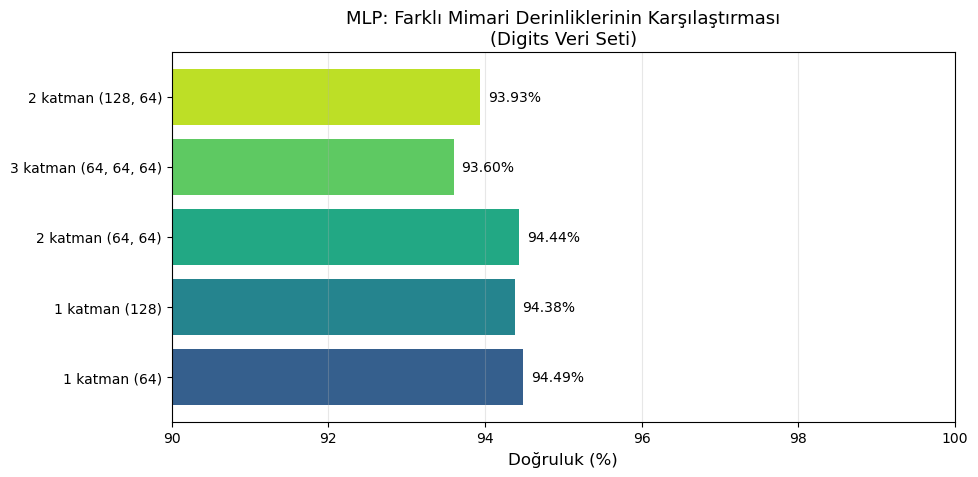

In [27]:
# Farklı gizli katman sayılarının MNIST üzerindeki etkisi
from sklearn.datasets import load_digits
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np
import matplotlib.pyplot as plt

# Küçük veri seti kullanıyoruz (hız için)
digits = load_digits()
X_digits, y_digits = digits.data, digits.target

print("🔬 Farklı gizli katman mimarilerinin karşılaştırması...")
print("   (Scikit-Learn'in küçük Digits veri seti kullanılıyor)\n")

mimariler = {
    '1 katman (64)': [64],
    '1 katman (128)': [128],
    '2 katman (64, 64)': [64, 64],
    '3 katman (64, 64, 64)': [64, 64, 64],
    '2 katman (128, 64)': [128, 64],
}

sonuclar = {}
for isim, katmanlar in mimariler.items():
    model = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=katmanlar, max_iter=500, random_state=42)
    )
    skorlar = cross_val_score(model, X_digits, y_digits, cv=3, scoring='accuracy')
    sonuclar[isim] = skorlar.mean()
    print(f"  {isim:<30}: {skorlar.mean()*100:.2f}% ± {skorlar.std()*100:.2f}%")

# Grafik
fig, ax = plt.subplots(figsize=(10, 5))
isimler = list(sonuclar.keys())
degerler = [v*100 for v in sonuclar.values()]
renkler = plt.cm.viridis(np.linspace(0.3, 0.9, len(isimler)))
bars = ax.barh(isimler, degerler, color=renkler)
ax.set_xlabel('Doğruluk (%)', fontsize=12)
ax.set_title('MLP: Farklı Mimari Derinliklerinin Karşılaştırması\n(Digits Veri Seti)', fontsize=13)
for bar, val in zip(bars, degerler):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, 
            f'{val:.2f}%', va='center', fontsize=10)
ax.set_xlim(90, 100)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('mimari_karsilastirma.png', dpi=120, bbox_inches='tight')
plt.show()

<a id='noron_sayisi'></a>
### 6.2 Katman Başına Nöron Sayısı

**Tarihsel yaklaşım:** Piramit yapı (her katmanda azalan nöron) — artık kullanılmıyor.

**Modern yaklaşım:** Tüm gizli katmanlarda **eşit sayıda nöron** — genellikle daha iyi sonuç.

**"Elastik Pantolon" (Stretch Pants) Stratejisi** — Vincent Vanhoucke:
- Tam uyumu arama, biraz büyük başla
- Erken durdurma ve düzenleme (regularization) ile overfitting'i engelle
- Darboğaz katmandan (bottleneck layer) kaçın — model kapasitesini kısıtlar

**Önemli Kural:** Katman başına nöron sayısını artırmak yerine, **katman sayısını artırmak** genellikle daha verimli.

Veri hazırlanıyor...
📏 Nöron Sayısı Seçimi Rehberi:

1. Giriş/Çıktı katmanları:
   → Görev tarafından belirlenir
   → Örnek: MNIST = 784 giriş, 10 çıktı

2. Gizli katman nöron sayısı:
   → Tipik aralık: 10 - 1000+
   → PCA analizi ile gerekli boyutu tahmin edebilirsin
   → Fashion MNIST: 95% varyansı korumak için 187 boyut gerekiyor
   → Dolayısıyla ilk katmanda 187'den büyük sayı seç

3. Darboğaz katman (bottleneck) ne zaman kullanılır?
   → Gürültü azaltmak için (kasıtlı boyut düşürme)
   → Temsil öğrenmesi (representation learning) için
   → Otoenkoderler gibi özel mimarilerde

🔬 Fashion MNIST PCA Analizi:
   %95 varyans için gereken boyut: 177
   %99 varyans için gereken boyut: 432
   Öneri: İlk gizli katmanda 177+ nöron kullan


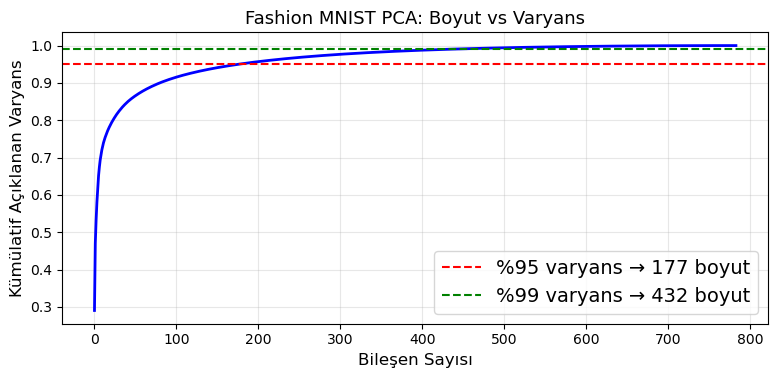


📝 Softplus Aktivasyonu Nedir?


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml

# --- EKSİK TANIMLAMA (DÜZELTME) ---
# X_train_f tanımlanmadığı için veriyi çekip isimlendiriyoruz
print("Veri hazırlanıyor...")
fashion_mnist = fetch_openml(name="Fashion-MNIST", as_frame=False, parser='auto')
X_train_f = fashion_mnist.data
# ---------------------------------

# Nöron sayısı seçimi rehberi
print("📏 Nöron Sayısı Seçimi Rehberi:\n")

print("1. Giriş/Çıktı katmanları:")
print("   → Görev tarafından belirlenir")
print("   → Örnek: MNIST = 784 giriş, 10 çıktı")

print("\n2. Gizli katman nöron sayısı:")
print("   → Tipik aralık: 10 - 1000+")
print("   → PCA analizi ile gerekli boyutu tahmin edebilirsin")
print("   → Fashion MNIST: 95% varyansı korumak için 187 boyut gerekiyor")
print("   → Dolayısıyla ilk katmanda 187'den büyük sayı seç")

print("\n3. Darboğaz katman (bottleneck) ne zaman kullanılır?")
print("   → Gürültü azaltmak için (kasıtlı boyut düşürme)")
print("   → Temsil öğrenmesi (representation learning) için")
print("   → Otoenkoderler gibi özel mimarilerde")

# Fashion MNIST için PCA analizi
print("\n🔬 Fashion MNIST PCA Analizi:")
# Hız için küçük örnek
sample_idx = np.random.RandomState(42).choice(len(X_train_f), 5000, replace=False)
X_sample = X_train_f[sample_idx]

pca = PCA().fit(X_sample)
kumulatif_varyans = np.cumsum(pca.explained_variance_ratio_)

boyut_95 = np.argmax(kumulatif_varyans >= 0.95) + 1
boyut_99 = np.argmax(kumulatif_varyans >= 0.99) + 1

print(f"   %95 varyans için gereken boyut: {boyut_95}")
print(f"   %99 varyans için gereken boyut: {boyut_99}")
print(f"   Öneri: İlk gizli katmanda {boyut_95}+ nöron kullan")



plt.figure(figsize=(8, 4))
plt.plot(kumulatif_varyans, 'b-', linewidth=2)
plt.axhline(0.95, color='r', linestyle='--', label=f'%95 varyans → {boyut_95} boyut')
plt.axhline(0.99, color='g', linestyle='--', label=f'%99 varyans → {boyut_99} boyut')
plt.xlabel('Bileşen Sayısı', fontsize=12)
plt.ylabel('Kümülatif Açıklanan Varyans', fontsize=12)
plt.title('Fashion MNIST PCA: Boyut vs Varyans', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_analizi.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n📝 Softplus Aktivasyonu Nedir?")


<a id='ogrenme_hizi'></a>
### 6.3 Öğrenme Hızı (Learning Rate)

Öğrenme hızı en kritik hiperparametredir.

**İdeal öğrenme hızı ≈ Maksimum öğrenme hızının yarısı**

**En iyi öğrenme hızını bulma yöntemi:**
1. Çok küçük bir öğrenme hızıyla başla (örn. $10^{-5}$)
2. Her iterasyonda katlayarak büyüt (örn. $10^{-5}$ → $10$ arası, 500 iterasyonda)
3. Kayıp fonksiyonunu öğrenme hızının logaritmasına karşı çiz
4. Kaybın en hızlı düştüğü noktanın biraz öncesini seç
5. Kayıp yükselmeden önceki noktadan ~10 kat daha küçük değeri kullan

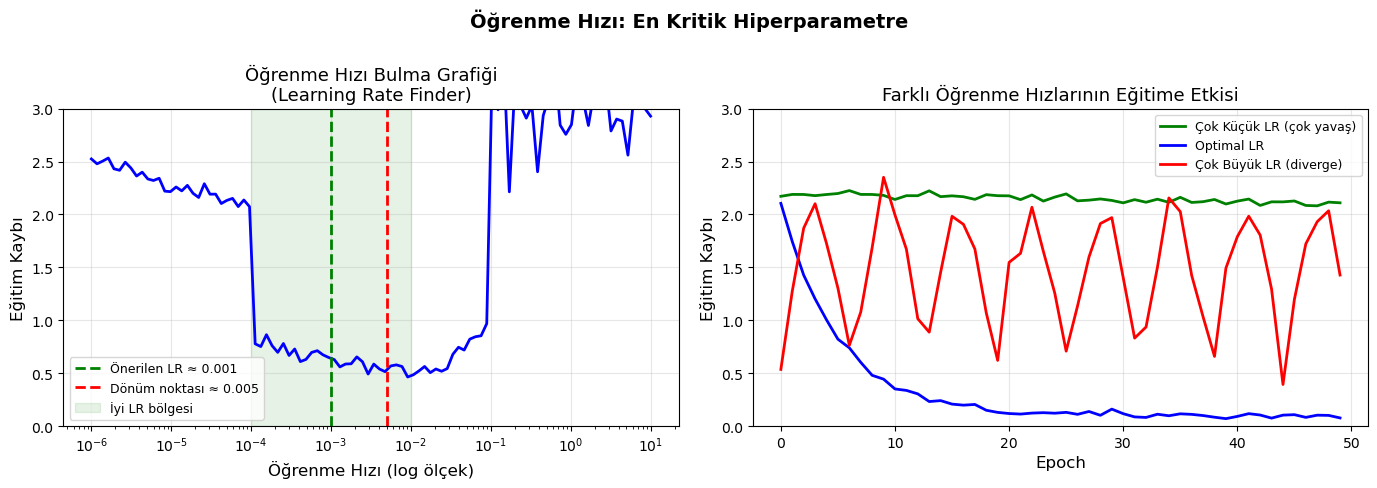

💡 Öğrenme Hızı Seçme Rehberi:
  ✓ Başlangıç noktası: 0.001 (Adam optimizer için)
  ✓ LR Finder: 1e-5'ten başla, katlayarak büyüt
  ✓ Optimal ≈ Kaybın dönüm noktasının 1/10'u
  ✓ Scikit-Learn'de warm_start=True ile iteratif güncelleme
  ✓ Diğer hiperparametreleri değiştirince LR'yi de yeniden ayarla!


In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Öğrenme hızı bulma simülasyonu
np.random.seed(42)
ogrenme_hizlari = np.logspace(-6, 1, 100)

# Simüle edilmiş kayıp eğrisi (gerçek eğitim değil, illüstrasyon)
def simulasyon_kayip(lr):
    if lr < 1e-4:
        return 2.5 - 20 * np.log10(lr/1e-6) * 0.01 + np.random.normal(0, 0.05)
    elif lr < 1e-2:
        return 0.8 - (np.log10(lr) - (-4)) * 0.15 + np.random.normal(0, 0.05)
    elif lr < 0.1:
        return 0.5 + (np.log10(lr) - (-2)) ** 2 * 0.5 + np.random.normal(0, 0.05)
    else:
        return 3.0 + np.random.normal(0, 0.3)

kayiplar = [simulasyon_kayip(lr) for lr in ogrenme_hizlari]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Öğrenme hızı bulma grafiği
ax1.semilogx(ogrenme_hizlari, kayiplar, 'b-', linewidth=2)
ax1.axvline(x=1e-3, color='g', linestyle='--', label='Önerilen LR ≈ 0.001', linewidth=2)
ax1.axvline(x=5e-3, color='r', linestyle='--', label='Dönüm noktası ≈ 0.005', linewidth=2)
ax1.fill_betweenx([0, 3], 1e-4, 1e-2, alpha=0.1, color='green', label='İyi LR bölgesi')
ax1.set_xlabel('Öğrenme Hızı (log ölçek)', fontsize=12)
ax1.set_ylabel('Eğitim Kaybı', fontsize=12)
ax1.set_title('Öğrenme Hızı Bulma Grafiği\n(Learning Rate Finder)', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 3)

# Farklı öğrenme hızlarının etkileri
epochs = np.arange(50)
ax2.plot(epochs, 2 * np.exp(-0.001 * epochs) + 0.2 + np.random.normal(0, 0.02, 50), 
         'g-', linewidth=2, label='Çok Küçük LR (çok yavaş)')
ax2.plot(epochs, 2 * np.exp(-0.2 * epochs) + 0.1 + np.random.normal(0, 0.02, 50), 
         'b-', linewidth=2, label='Optimal LR')
ax2.plot(epochs, np.abs(np.sin(epochs * 0.5)) * 1.5 + 0.5 + np.random.normal(0, 0.1, 50), 
         'r-', linewidth=2, label='Çok Büyük LR (diverge)')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Eğitim Kaybı', fontsize=12)
ax2.set_title('Farklı Öğrenme Hızlarının Eğitime Etkisi', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 3)

plt.suptitle('Öğrenme Hızı: En Kritik Hiperparametre', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ogrenme_hizi.png', dpi=120, bbox_inches='tight')
plt.show()

print("💡 Öğrenme Hızı Seçme Rehberi:")
print("  ✓ Başlangıç noktası: 0.001 (Adam optimizer için)")
print("  ✓ LR Finder: 1e-5'ten başla, katlayarak büyüt")
print("  ✓ Optimal ≈ Kaybın dönüm noktasının 1/10'u")
print("  ✓ Scikit-Learn'de warm_start=True ile iteratif güncelleme")
print("  ✓ Diğer hiperparametreleri değiştirince LR'yi de yeniden ayarla!")

<a id='batch'></a>
### 6.4 Batch Boyutu

Batch boyutu model performansını ve eğitim hızını önemli ölçüde etkiler.

| Küçük Batch (2-32) | Büyük Batch (256-8192+) |
|---|---|
| Daha gürültülü gradyanlar | Daha kararlı gradyanlar |
| Daha iyi genelleme (bazı çalışmalar) | GPU'yu verimli kullanır |
| Eğitim daha yavaş (batch başına) | Saniyede daha fazla örnek |
| Yerel minimuma takılma riski düşük | Bazen instabilite |
| Yann LeCun: max 32 önerir | Learning rate warmup ile büyük batch çalışır |

**Strateji:** Büyük batch ile başla + learning rate warmup. Eğer instabite veya zayıf sonuç varsa küçük batch'e geç.

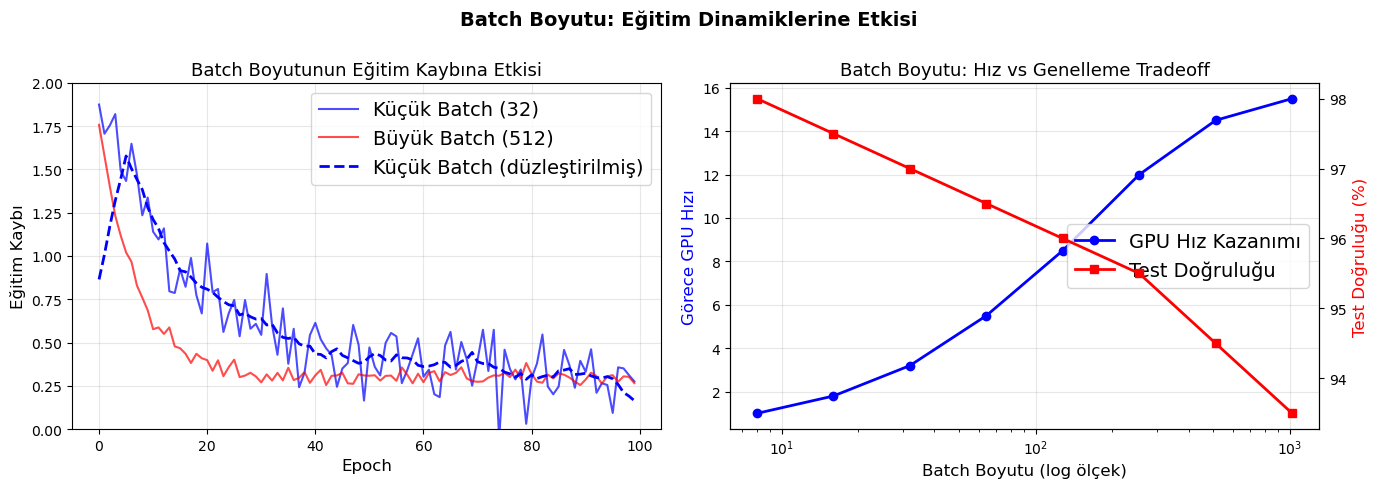

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Batch boyutunun eğitim üzerindeki etkisini görselleştir
np.random.seed(42)
epochs = np.arange(100)

# Simüle edilmiş kayıp eğrileri
def kayip_egri(epochs, gurultu=0.1, yavas=False):
    hiz = 0.05 if yavas else 0.15
    return 1.5 * np.exp(-hiz * epochs) + 0.3 + np.random.normal(0, gurultu, len(epochs))

kucuk_batch = kayip_egri(epochs, gurultu=0.15, yavas=True)  # gürültülü ama iyi genelleme
buyuk_batch = kayip_egri(epochs, gurultu=0.03, yavas=False)  # kararlı ama kötü genelleme

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Eğitim kaybı
axes[0].plot(epochs, kucuk_batch, 'b-', alpha=0.7, linewidth=1.5, label='Küçük Batch (32)')
axes[0].plot(epochs, buyuk_batch, 'r-', alpha=0.7, linewidth=1.5, label='Büyük Batch (512)')
axes[0].plot(epochs, np.convolve(kucuk_batch, np.ones(10)/10, mode='same'), 
             'b--', linewidth=2, label='Küçük Batch (düzleştirilmiş)')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Eğitim Kaybı', fontsize=12)
axes[0].set_title('Batch Boyutunun Eğitim Kaybına Etkisi', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 2)

# Batch boyutu ve hız tradeoff
batch_boyutlari = [8, 16, 32, 64, 128, 256, 512, 1024]
gorece_hiz = [1, 1.8, 3.2, 5.5, 8.5, 12.0, 14.5, 15.5]  # GPU hız kazanımı
genelleme = [98, 97.5, 97, 96.5, 96, 95.5, 94.5, 93.5]  # test doğruluğu

ax2 = axes[1]
color1 = 'blue'
color2 = 'red'

ax2_twin = ax2.twinx()
ax2.semilogx(batch_boyutlari, gorece_hiz, 'b-o', linewidth=2, label='GPU Hız Kazanımı')
ax2_twin.semilogx(batch_boyutlari, genelleme, 'r-s', linewidth=2, label='Test Doğruluğu')

ax2.set_xlabel('Batch Boyutu (log ölçek)', fontsize=12)
ax2.set_ylabel('Görece GPU Hızı', fontsize=12, color=color1)
ax2_twin.set_ylabel('Test Doğruluğu (%)', fontsize=12, color=color2)
ax2.set_title('Batch Boyutu: Hız vs Genelleme Tradeoff', fontsize=13)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='center right')
ax2.grid(True, alpha=0.3)

plt.suptitle('Batch Boyutu: Eğitim Dinamiklerine Etkisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('batch_boyutu.png', dpi=120, bbox_inches='tight')
plt.show()

<a id='diger'></a>
### 6.5 Diğer Hiperparametreler

In [34]:
print("⚙️  Diğer Önemli Hiperparametreler:\n")

print("1. 🚀 Optimizer (Eniyileyici):")
print("   → Standart SGD: Basit ama yavaş")
print("   → Adam: Modern uygulamaların çoğunda varsayılan")
print("   → AdaGrad, RMSProp: Özel durumlarda faydalı")
print("   → PyTorch/TF'ye geçince daha fazla seçenek var")

print("\n2. 🎯 Aktivasyon Fonksiyonu:")
print("   → Gizli katmanlar: ReLU (varsayılan)")
print("   → Sigmoid: Çıktıda ikili sınıflama için")
print("   → Softmax: Çıktıda çok sınıflı sınıflama için")
print("   → Leaky ReLU, ELU: Özel durumlarda ReLU'ya alternatif")

print("\n3. 🔄 İterasyon/Epoch Sayısı:")
print("   → Genellikle ayarlamaya gerek yok")
print("   → Erken Durdurma (Early Stopping) kullan!")
print("   → Doğrulama kaybı durduğunda eğitimi sonlandır")

print("\n4. 🛡️  Düzenleme (Regularization):")
print("   → L2 (Ridge): Ağırlıkları küçük tutar (alpha parametresi)")
print("   → Dropout: Eğitimde rastgele nöronları devre dışı bırakır")
print("   → Batch Normalization: Katman çıktılarını normalize eder")

print("\n📌 Kritik Kural:")
print("   Herhangi bir hiperparametreyi değiştirdiğinde")
print("   öğrenme hızını da yeniden ayarla!")
print("   (Öğrenme hızı diğer HP'lere bağımlıdır)")

⚙️  Diğer Önemli Hiperparametreler:

1. 🚀 Optimizer (Eniyileyici):
   → Standart SGD: Basit ama yavaş
   → Adam: Modern uygulamaların çoğunda varsayılan
   → AdaGrad, RMSProp: Özel durumlarda faydalı
   → PyTorch/TF'ye geçince daha fazla seçenek var

2. 🎯 Aktivasyon Fonksiyonu:
   → Gizli katmanlar: ReLU (varsayılan)
   → Sigmoid: Çıktıda ikili sınıflama için
   → Softmax: Çıktıda çok sınıflı sınıflama için
   → Leaky ReLU, ELU: Özel durumlarda ReLU'ya alternatif

3. 🔄 İterasyon/Epoch Sayısı:
   → Genellikle ayarlamaya gerek yok
   → Erken Durdurma (Early Stopping) kullan!
   → Doğrulama kaybı durduğunda eğitimi sonlandır

4. 🛡️  Düzenleme (Regularization):
   → L2 (Ridge): Ağırlıkları küçük tutar (alpha parametresi)
   → Dropout: Eğitimde rastgele nöronları devre dışı bırakır
   → Batch Normalization: Katman çıktılarını normalize eder

📌 Kritik Kural:
   Herhangi bir hiperparametreyi değiştirdiğinde
   öğrenme hızını da yeniden ayarla!
   (Öğrenme hızı diğer HP'lere bağımlıdır)


In [ ]:
# RandomizedSearchCV ile hiperparametre optimizasyonu
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.datasets import load_digits
import numpy as np

# Küçük veri seti ile hızlı demo
digits = load_digits()
X, y = digits.data, digits.target

# Hiperparametre arama uzayı
param_dist = {
    'mlpclassifier__hidden_layer_sizes': [
        [64], [128], [64, 64], [128, 64], [64, 64, 64]
    ],
    'mlpclassifier__alpha': [1e-4, 1e-3, 1e-2, 1e-1],
    'mlpclassifier__learning_rate_init': [1e-3, 5e-3, 1e-2],
    'mlpclassifier__activation': ['relu', 'tanh'],
}

model = make_pipeline(
    StandardScaler(),
    MLPClassifier(max_iter=200, early_stopping=True, random_state=42)
)

print("🔍 RandomizedSearchCV ile hiperparametre optimizasyonu...")
print("   (10 iterasyon, 3-katlı çapraz doğrulama)\n")

search = RandomizedSearchCV(
    model, param_dist, n_iter=10, cv=3, 
    scoring='accuracy', n_jobs=-1, random_state=42
)
search.fit(X, y)

print(f"✅ En iyi doğruluk: {search.best_score_*100:.2f}%")
print(f"\n📋 En iyi hiperparametreler:")
for k, v in search.best_params_.items():
    parametre_adi = k.replace('mlpclassifier__', '')
    print(f"   {parametre_adi}: {v}")

print("\n💡 Not: Fashion MNIST gibi büyük veri setlerinde")
print("   arama uzayı çok daha büyük olacaktır.")
print("   PyTorch ile Optuna gibi araçlar daha verimlidir.")

Error patching args (debugger not attached to subprocess).
Traceback (most recent call last):
  File "/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 527, in patch_args
    new_args.append(_get_python_c_args(host, port, code, unquoted_args, SetupHolder.setup))
  File "/Users/livanurkaranfil/opt/anaconda3/lib/python3.9/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 179, in _get_python_c_args
    if '__future__' in code:
TypeError: a bytes-like object is required, not 'str'


🔍 RandomizedSearchCV ile hiperparametre optimizasyonu...
   (10 iterasyon, 3-katlı çapraz doğrulama)



---
<a id='ozet'></a>
## 7. 📝 Bölüm Özeti

### Temel Kavramlar

| Kavram | Açıklama |
|---|---|
| **YSA (ANN)** | Biyolojik beinden esinlenen makine öğrenmesi modeli |
| **TLU/Perceptron** | En basit YSA: ağırlıklı toplam + adım fonksiyonu |
| **MLP** | Çok katmanlı perceptron; XOR gibi doğrusal olmayan problemleri çözer |
| **Geri Yayılım** | Zincir kuralı + ters-mod autodiff ile gradyan hesaplama |
| **Aktivasyon Fns** | Doğrusal olmayanlık için kritik: ReLU, Sigmoid, Tanh, Softmax |
| **Erken Durdurma** | Overfitting'i önlemek için en pratik yöntem |
| **Adam** | Çoğu uygulamada tercih edilen modern optimizer |

### Mimari Seçim Rehberi

```
REGRESYON GÖREVI:
  Çıktı nöronu: 1 (tek değer) veya N (çoklu değer)
  Çıktı aktivasyonu: Yok (genellikle)
  Kayıp: MSE veya Huber

İKİLİ SINIFLANDIRMA:
  Çıktı nöronu: 1
  Çıktı aktivasyonu: Sigmoid → P(pozitif sınıf)
  Kayıp: İkili çapraz entropi

ÇOK SINIFLI SINIFLANDIRMA:
  Çıktı nöronu: N (sınıf sayısı kadar)
  Çıktı aktivasyonu: Softmax → P(her sınıf)
  Kayıp: Kategorik çapraz entropi

ÇOK ETİKETLİ SINIFLANDIRMA:
  Çıktı nöronu: N (etiket sayısı kadar)
  Çıktı aktivasyonu: Sigmoid (her etiket bağımsız)
  Kayıp: İkili çapraz entropi
```

### Sıradaki Adımlar

- **Bölüm 10:** PyTorch ile GPU hızlı MLP eğitimi ve daha karmaşık modeller
- **Bölüm 11:** Derin ağlarda eğitim teknikleri (Batch Normalization, Dropout, vb.)
- **İleri Mimariler:** CNN (Evrişimsel), RNN/LSTM (Tekrarlayan), Transformer

---
<a id='alistirmalar'></a>
## 8. 🏋️ Alıştırmalar

Kitaptaki alıştırmalar ve Türkçe açıklamalar:

**Alıştırma 1:** TensorFlow Playground'u deneyin.  
🔗 https://playground.tensorflow.org

---

**Alıştırma 2:** A ⊕ B (XOR) işlemini orijinal artificial neurons ile hesaplayan bir ANN çizin.  
İpucu: A ⊕ B = (A ∧ ¬B) ∨ (¬A ∧ B)

---

**Alıştırma 3:** Neden logistic regression classifier (lojistik regresyon sınıflandırıcısı), klasik perceptron'dan (algılayıcıdan) genellikle daha iyidir?

*Cevap:*  
- Klasik Perceptron yalnızca **linearly separable** (doğrusal ayrılabilir) veri setlerinde convergence (yakınsama) sağlar.
- **Class probability** (sınıf olasılığı) üretmez — sadece 0 veya 1 döner.
- Logistic Regression ise doğrusal ayrılamayan veri setlerinde de makul çözümlere ulaşır.
- **Probabilistic output** (olasılıksal çıktı) üretir → daha yorumlanabilir.
- Perceptron'u Logistic Regression'a dönüştürmek için: step function yerine **sigmoid activation** kullan + **cross-entropy loss** ile **gradient descent** uygula.

---

**Alıştırma 4:** Sigmoid activation function neden ilk MLP'lerin eğitiminde kritik bir bileşendi?

*Cevap:*  
- **Step function** her yerde düzdür (flat) → **derivative** (türev) sıfır → gradient descent hiç hareket edemez.
- **Sigmoid function** ise her yerde sıfırdan farklı, iyi tanımlı bir türeve sahip → gradient descent her adımda ilerleme kaydeder.
- Bu nedenle Rumelhart ve ekibi (1985) backpropagation'ı tanıtırken step function'ı sigmoid ile değiştirdi.

---

**Alıştırma 5:** Üç popüler activation function (aktivasyon fonksiyonu) sayın.

*Cevap:*  
- **Step function** (adım fonksiyonu) — tarihsel önemi var, artık kullanılmıyor  
- **Sigmoid function** (lojistik fonksiyon) — binary classification output'u için  
- **Tanh function** (hiperbolik tanjant) — zero-centered, sigmoid'den hızlı convergence  
- **ReLU function** (Rectified Linear Unit) — modern ağlarda gizli katmanlar için varsayılan  
- (Bonus: Bölüm 11'de ELU, Leaky ReLU, SELU gibi ReLU varyantları incelenir)

---

**Alıştırma 6:** Bir MLP: 10 nöronlu input layer (giriş katmanı), 50 nöronlu hidden layer (gizli katman), 3 nöronlu output layer (çıktı katmanı). Tümü ReLU.

| Bileşen | Şekil | Açıklama |
|---|---|---|
| **X** (girdi) | m × 10 | m = mini-batch boyutu |
| **W_h** (gizli ağırlık) | 10 × 50 | 10 giriş → 50 nöron |
| **b_h** (gizli bias) | 50 | Her gizli nöron için 1 bias |
| **W_o** (çıktı ağırlık) | 50 × 3 | 50 nöron → 3 çıktı |
| **b_o** (çıktı bias) | 3 | Her çıktı nöronu için 1 bias |
| **Y** (çıktı) | m × 3 | m örnek, 3 sınıf |

Denklem: **Y** = ReLU(ReLU(**X** **W_h** + **b_h**) **W_o** + **b_o**)

---

**Alıştırma 7:** Hangi durumlarda kaç output neuron (çıktı nöronu) gerekir?

| Görev | Output neurons | Activation | Loss |
|---|---|---|---|
| Spam/ham (binary) | 1 | Sigmoid | Binary cross-entropy |
| MNIST (10 rakam) | 10 | Softmax | Categorical cross-entropy |
| Ev fiyatı (reg.) | 1 | Yok (linear) | MSE |

*Not: Hedef değer çok büyük aralıklarda değişiyorsa log(hedef) tahmin etmek daha iyi çalışabilir.*

---

**Alıştırma 8:** Backpropagation (geri yayılım) nedir? Reverse-mode autodiff'ten farkı nedir?

*Cevap:*
- **Backpropagation**: ANN eğitmek için kullanılan genel teknik.
  - Mini-batch bazlı gradient descent adımlarını binlerce/milyonlarca kez uygular.
  - Her adım için **reverse-mode autodiff** kullanarak gradyanları hesaplar.
- **Reverse-mode autodiff**: Gradyanları verimli hesaplayan matematiksel teknik.
  - Forward pass: Tüm değerleri hesapla, sakla.
  - Backward pass: Zincir kuralıyla tüm gradyanları tek seferde hesapla.
- **Fark**: Backpropagation = eğitim süreci; Reverse-mode autodiff = gradyan hesaplama tekniği.
  Backpropagation, reverse-mode autodiff'i kullanır ama ondan daha geniş bir kavramdır.

---

**Alıştırma 9:** Temel MLP'de ayarlanabilecek tüm hyperparameters (hiperparametreler) nelerdir?

- **Number of hidden layers** (gizli katman sayısı): 1'den başla, overfitting'e kadar artır
- **Neurons per hidden layer** (katman başına nöron sayısı): 10–1000+
- **Activation function** (aktivasyon fonksiyonu): Gizli → ReLU; Çıktı → göreve göre
- **Weight initialization** (ağırlık başlatma): He, Glorot, random
- **Optimizer** (eniyileyici): SGD, Adam, RMSProp
- **Learning rate** (öğrenme hızı): En kritik hiperparametre
- **Batch size** (parti boyutu): 2–8192
- **Regularization** (düzenlileştirme): L1/L2 alpha, dropout oranı
- **Number of epochs/iterations** (epoch sayısı): Early stopping ile genellikle otomatik

*Overfitting durumunda:* Katman/nöron sayısını azalt, daha fazla regularization ekle, early stopping uygula, daha fazla veri topla.

---
### Alıştırma 10 — CoverType Dataset ile Derin MLP

In [2]:
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split

# ── CoverType Veri Setini Yükleme ─────────────────────────────────────────────
# fetch_covtype(): Orman örtü tipini tahmin etmeye yönelik veri seti.
#   Kaynak: ABD Orman Servisi (US Forest Service)
#   Örnekler: ~581,012 (büyük veri seti)
#   Features (özellikler): 54 sayısal/kategorik özellik
#     - Elevation (yükseklik), Aspect (yön), Slope (eğim)
#     - Horizontal/Vertical distance to hydrology
#     - Hillshade özellikleri
#     - 4 Wilderness Area (alanı ikili vektör olarak kodlanmış)
#     - 40 Soil Type (toprak tipi ikili vektör olarak kodlanmış)
#   Target (hedef): 7 sınıf (1-7) → 7 farklı orman örtü tipi
#     1: Spruce/Fir (Ladin/Köknar)
#     2: Lodgepole Pine
#     3: Ponderosa Pine
#     4: Cottonwood/Willow
#     5: Aspen (Kavak)
#     6: Douglas-fir
#     7: Krummholz

covtype = fetch_covtype()

print("CoverType veri seti yüklendi!")
print(f"  Veri boyutu    : {covtype.data.shape}")
print(f"  Özellik sayısı : {covtype.data.shape[1]}")
print(f"  Örnek sayısı   : {covtype.data.shape[0]:,}")
print(f"  Sınıf sayısı   : {len(set(covtype.target))} → {sorted(set(covtype.target))}")
print()

# ── Train/Test Split ───────────────────────────────────────────────────────────
# random_state=42: Reproducibility için sabit tohum
# test_size: Belirtilmediğinde varsayılan %25
# Stratified split yapılmıyor — veri zaten dengeli dağılmış
X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(
    covtype.data, covtype.target, random_state=42
)
print(f"Training set  : {X_train_cv.shape[0]:,} örnek")
print(f"Test set      : {X_test_cv.shape[0]:,} örnek")

CoverType veri seti yüklendi!
  Veri boyutu    : (581012, 54)
  Özellik sayısı : 54
  Örnek sayısı   : 581,012
  Sınıf sayısı   : 7 → [1, 2, 3, 4, 5, 6, 7]

Training set  : 435,759 örnek
Test set      : 145,253 örnek


In [6]:
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
# ── Derin MLP Tanımlama ve Eğitim ────────────────────────────────────────────
# Hedef: Test setinde %93'ün üzerinde accuracy
# Strateji: Daha derin ağ + StandardScaler + early stopping

# hidden_layer_sizes=[200, 100, 50]:
#   3 gizli katman — azalan boyutlu piramit yapı.
#   İlk katman daha geniş → daha fazla düşük seviye pattern (örüntü) öğrensin.
#   Son katman daha dar → yüksek seviye soyut özelliklere yoğunlaşsın.
#   Toplam parametre:
#     Katman 1: 54×200 + 200   = 11,000
#     Katman 2: 200×100 + 100  = 20,100
#     Katman 3: 100×50  + 50   = 5,050
#     Çıktı   : 50×7   + 7    = 357
#     TOPLAM  : 36,507 parametre

# StandardScaler burada MinMaxScaler'dan daha uygun:
#   Yükseklik, eğim gibi özellikler farklı ölçekte ve dağılımda.
#   StandardScaler her özelliği mean=0, std=1 yaparak eşitler.

mlp_clf_cv = MLPClassifier(
    hidden_layer_sizes=[200, 100, 50],
    early_stopping=True,
    verbose=True,
    random_state=42
)

pipeline_cv = make_pipeline(StandardScaler(), mlp_clf_cv)

print("CoverType için MLP eğitimi başlıyor...")
print(f"  Mimari     : 54 → 200 → 100 → 50 → 7")
print(f"  Ölçekleme  : StandardScaler")
print(f"  Early stop : Açık")
print("=" * 60)

# Büyük veri seti (~435,000 eğitim örneği) → Uzun sürebilir
pipeline_cv.fit(X_train_cv, y_train_cv)

CoverType için MLP eğitimi başlıyor...
  Mimari     : 54 → 200 → 100 → 50 → 7
  Ölçekleme  : StandardScaler
  Early stop : Açık
Iteration 1, loss = 0.54176112
Validation score: 0.806751
Iteration 2, loss = 0.42014984
Validation score: 0.830847
Iteration 3, loss = 0.36860865
Validation score: 0.853589
Iteration 4, loss = 0.33598244
Validation score: 0.864536
Iteration 5, loss = 0.31272332
Validation score: 0.869768
Iteration 6, loss = 0.29537023
Validation score: 0.884111
Iteration 7, loss = 0.28015485
Validation score: 0.883284
Iteration 8, loss = 0.26937433
Validation score: 0.888126
Iteration 9, loss = 0.26004990
Validation score: 0.893129
Iteration 10, loss = 0.25201742
Validation score: 0.892188
Iteration 11, loss = 0.24352796
Validation score: 0.898476
Iteration 12, loss = 0.23721328
Validation score: 0.901941
Iteration 13, loss = 0.23194199
Validation score: 0.904053
Iteration 14, loss = 0.22549482
Validation score: 0.905567
Iteration 15, loss = 0.22150953
Validation score: 0.907

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpclassifier',
                 MLPClassifier(early_stopping=True,
                               hidden_layer_sizes=[200, 100, 50],
                               random_state=42, verbose=True))])

In [7]:
# ── CoverType Test Seti Değerlendirme ─────────────────────────────────────────
# pipeline.score(): Pipeline'ın tamamını kullanarak accuracy hesaplar.
#   1. StandardScaler: X_test_cv'yi eğitimden öğrenilen mean/std ile ölçekler
#   2. MLPClassifier: Ölçeklenmiş veri üzerinde tahmin yapar
#   3. accuracy = doğru tahminler / toplam tahminler

test_acc = pipeline_cv.score(X_test_cv, y_test_cv)

print(f"\nCoverType Test Accuracy (doğruluk): {test_acc * 100:.2f}%")
print()

if test_acc >= 0.93:
    print("🎉 Hedef aşıldı! %93 doğruluk sağlandı!")
else:
    print(f"📈 Mevcut: {test_acc*100:.2f}% | Hedef: %93")
    print("\nDaha iyi sonuç için deneyebilecekleriniz:")
    print("  1. hidden_layer_sizes'ı büyüt: [300, 200, 100]")
    print("  2. Daha fazla katman ekle: [200, 150, 100, 50]")
    print("  3. max_iter'i artır ve early stopping kapatarak uzun eğit")
    print("  4. RandomizedSearchCV ile hiperparametre arama yap")
    print("  5. PyTorch + GPU kullan → çok daha hızlı büyük ağlar")

print()
print("Not: RandomizedSearchCV ile hyperparameter tuning (hiperparametre ayarlama)")
print("  yapmak istiyorsanız, aşağıdaki arama uzayını kullanabilirsiniz:")
print("""
param_dist = {
    'mlpclassifier__hidden_layer_sizes': [[100], [200,100], [300,200,100]],
    'mlpclassifier__alpha'             : [1e-4, 1e-3, 1e-2],
    'mlpclassifier__learning_rate_init': [1e-3, 5e-3, 1e-2],
}
""")


CoverType Test Accuracy (doğruluk): 93.95%

🎉 Hedef aşıldı! %93 doğruluk sağlandı!

Not: RandomizedSearchCV ile hyperparameter tuning (hiperparametre ayarlama)
  yapmak istiyorsanız, aşağıdaki arama uzayını kullanabilirsiniz:

param_dist = {
    'mlpclassifier__hidden_layer_sizes': [[100], [200,100], [300,200,100]],
    'mlpclassifier__alpha'             : [1e-4, 1e-3, 1e-2],
    'mlpclassifier__learning_rate_init': [1e-3, 5e-3, 1e-2],
}

